# Reversal Error × Stimulation Analysis
### Digit Span Backwards — Can stimulation explain reversal failures?

**Hypothesis:** Stimulation during cognitive windows may impair digit reversal, causing:
- `PARTIAL_REVERSAL` — last 2 digits of the presented sequence stay fixed at the end of the
  response; remaining digits reverse to the front (e.g. 123→312, 1234→4312)

Only PARTIAL_REVERSAL trials are included: S2 T7/T10/T14, S3 T4/T7/T9/T11/T12 (8 trials total).

**Structure:**
1. Per-trial LFP plots — visualise digit sequence, response, stim, event markers (S2 then S3)
2. Error counts by stim state
3. Window-level stats: p-value (Fisher's Exact) + Cohen's d per window × error group
4. Summary tables + CSV export

## Cell 1 — Imports

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MultipleLocator
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        130,
    'savefig.dpi':       160,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# ── Colour constants ─────────────────────────────────────────────────────────
C_ON   = '#1A56DB'
C_OFF  = '#90A4AE'
C_TRACE      = '#1A56DB'
FIX_COLOR    = '#1565C0'
STIM_COLOR   = '#AD1457'
C_CS         = '#E65100'
C_CE         = '#2E7D32'
C_FB_S       = '#6D4C41'
C_FB_E       = '#4E342E'
C_STIM_ON_SHADE  = '#BBDEFB'
C_STIM_OFF_SHADE = '#EEEEEE'
C_CHOICE_SHADE   = '#FFF9C4'
C_FB_SHADE       = '#F3E5F5'
CORRECT_BG   = '#F1F8E9'
INCORRECT_BG = '#FFEBEE'
STIM_ON_COLOR  = '#0D47A1'
STIM_OFF_COLOR = '#90A4AE'

STIM_THRESHOLD = 2.0
PAD            = 2500   # ms padding around each trial window

ERROR_META = {
    'PARTIAL_REVERSAL': dict(label='Partial Reversal', color='#F9A825', short='Partial'),
    'CORRECT':          dict(label='Correct',          color='#2E7D32', short='Correct'),
}
ERROR_ORDER     = ['PARTIAL_REVERSAL', 'CORRECT']
# Only PARTIAL_REVERSAL trials are analysed
REVERSAL_ERRORS = ['PARTIAL_REVERSAL']

WINDOW_ORDER  = ['Fixation','Stimulus','Choice','Feedback']
WINDOW_COLORS = {
    'Fixation': '#7B1FA2',
    'Stimulus': '#E65100',
    'Choice':   '#1565C0',
    'Feedback': '#2E7D32',
}

print('Imports OK')

Imports OK


## Cell 2 — File Paths  ← EDIT THESE

In [3]:
JSON_PATH_S2   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json")
CSV_PATH_S2    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv")
EVENTS_PATH_S2 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv")
OUT_DIR_S2     = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2")

JSON_PATH_S3   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json")
CSV_PATH_S3    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv")
EVENTS_PATH_S3 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv")
OUT_DIR_S3     = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3")

COMBINED_DIR = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Combined")
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

# ── Target trials — PARTIAL REVERSAL only ────────────────────────────────────
# Session 2: T7(PARTIAL), T10(PARTIAL), T14(PARTIAL)   [T12 excluded — was NR_partial]
# Session 3: T4(PARTIAL), T7(PARTIAL), T9(PARTIAL), T11(PARTIAL), T12(PARTIAL)
TARGET_TRIALS_S2 = [7, 10, 14]
TARGET_TRIALS_S3 = [4, 7, 9, 11, 12]

print('Paths set.')
print(f'S2 PARTIAL REVERSAL trials: {TARGET_TRIALS_S2}')
print(f'S3 PARTIAL REVERSAL trials: {TARGET_TRIALS_S3}')

Paths set.
S2 PARTIAL REVERSAL trials: [7, 10, 14]
S3 PARTIAL REVERSAL trials: [4, 7, 9, 11, 12]


## Cell 3 — Pipeline Functions (alignment, mA trace, stim classification)

In [4]:
def load_session_data(json_path, csv_path, events_path):
    """
    Load all raw data for one session.
    Returns: report, eprime_df, ev_df, meta, to_rel, ticks_rel, raw_mAs, ymax
    """
    with open(json_path) as f:
        report = json.load(f)
    eprime_df = pd.read_csv(csv_path,    encoding='utf-8-sig', low_memory=False)
    ev_df     = pd.read_csv(events_path, encoding='utf-8-sig', low_memory=False)

    meta = dict(
        subject = str(eprime_df['Subject'].iloc[0]),
        session = str(eprime_df['Session'].iloc[0]),
        date    = str(eprime_df['SessionDate'].iloc[0]),
    )

    # Alignment anchor
    stim_tick = None
    for stream in report['BrainSenseLfp']:
        prev = None
        for pkt in stream['LfpData']:
            curr = pkt['Left']['mA']
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_tick = pkt['TicksInMs']; break
            prev = curr
        if stim_tick: break
    assert stim_tick, 'No 0→>0 mA transition found!'

    welcome_ms    = int(eprime_df['Welcome.TargetOnsetTime'].iloc[0])
    MANUAL_OFFSET = stim_tick - welcome_ms
    def to_rel(ms): return float(ms) + MANUAL_OFFSET - stim_tick

    # mA trace
    ticks, mAs = [], []
    for stream in report['BrainSenseLfp']:
        for pkt in stream['LfpData']:
            ticks.append(pkt['TicksInMs'])
            mAs.append(pkt['Left']['mA'])
    ticks = np.array(ticks, dtype=float)
    mAs   = np.array(mAs,   dtype=float)
    order = np.argsort(ticks)
    ticks, mAs = ticks[order], mAs[order]
    ticks_rel  = ticks - stim_tick
    ymax       = float(mAs.max()) * 1.45

    print(f"Loaded: Subject={meta['subject']}  Session={meta['session']}  "
          f"Date={meta['date']}  mA_max={mAs.max():.1f}")
    return report, eprime_df, ev_df, meta, to_rel, ticks_rel, mAs, ymax


def stim_frac(t0, t1, ticks_rel, mAs, threshold=STIM_THRESHOLD):
    """Fraction of [t0,t1] with mA >= threshold. Nearest-sample fallback."""
    if t0 is None or t1 is None or t1 <= t0: return np.nan
    mask = (ticks_rel >= t0) & (ticks_rel <= t1)
    tr, tm = ticks_rel[mask], mAs[mask]
    if len(tr) < 2:
        idx = int(np.argmin(np.abs(ticks_rel - (t0+t1)/2)))
        return 1.0 if mAs[idx] >= threshold else 0.0
    dt = np.diff(tr); mid = (tm[:-1]+tm[1:])/2
    total = tr[-1]-tr[0]
    if total <= 0: return 1.0 if tm[0] >= threshold else 0.0
    return float(np.sum(dt[mid >= threshold]) / total)


def get_stim_segs(x_lo, x_hi, ticks_rel, mAs, threshold=STIM_THRESHOLD):
    """Return (on_segs, off_segs) for shading a trial window."""
    mask = (ticks_rel >= x_lo-1000) & (ticks_rel <= x_hi+1000)
    tr, tm = ticks_rel[mask], mAs[mask]
    on_segs, off_segs = [], []
    if len(tr) == 0: return on_segs, off_segs
    in_stim = tm[0] >= threshold
    seg0 = tr[0]
    for j in range(1, len(tr)):
        is_on = tm[j] >= threshold
        if is_on and not in_stim:
            off_segs.append((max(seg0,x_lo), min(tr[j],x_hi)))
            seg0=tr[j]; in_stim=True
        elif not is_on and in_stim:
            on_segs.append((max(seg0,x_lo), min(tr[j],x_hi)))
            seg0=tr[j]; in_stim=False
    final = min(x_hi, float(ticks_rel[-1]))
    (on_segs if in_stim else off_segs).append((max(seg0,x_lo), final))
    return on_segs, off_segs

def classify_error(acc, cresp_int, resp_int, num_digits):
    """
    Classify a Digit Span Backwards response.

    Partial reversal definition (last 2 digits stay the same):
      - The first 2 digits of the PRESENTED sequence remain at the END of the response.
      - The remaining trailing digits reverse and move to the front.
      - Formula:  partial_resp = reverse(pres[2:]) + pres[:2]
      - E.g.  presented=123  -> partial=312   (last 2 of response = '12')
              presented=1234 -> partial=4312  (last 2 of response = '12')
              presented=12345-> partial=54312 (last 2 of response = '12')
    """
    nd = int(num_digits)
    if acc == 1: return 'CORRECT'
    cresp = str(int(cresp_int)).zfill(nd)
    resp  = str(int(resp_int)).zfill(nd)
    pres  = cresp[::-1]          # presented order (reverse of correct answer)

    # NO_REVERSAL_exact: patient responds with the presented (forward) order
    if resp == pres:
        return 'NO_REVERSAL_exact'

    # Partial reversal: last 2 digits of presented stay at end; rest reverses to front
    if nd >= 3:
        partial_resp = pres[2:][::-1] + pres[:2]
        if resp == partial_resp:
            return 'PARTIAL_REVERSAL'

    # NO_REVERSAL_partial: starts with wrong digit (not the last presented digit)
    if resp[0] != pres[-1]:
        return 'NO_REVERSAL_partial'

    return 'OTHER_ERROR'


print('Pipeline functions defined.')

Pipeline functions defined.


## Cell 4 — Build Trial Table

In [5]:
def build_trials(eprime_df, ev_df, to_rel, ticks_rel, mAs, sess_label,
                  target_trials=None):
    """
    Returns list of trial dicts with all timing, digit sequences,
    error classification, and per-window stim_on flags.
    target_trials: list of trial numbers to keep (None = all trials).
    """
    # Digit sequences from E-Prime flat list
    digit_rows = eprime_df['Digit'].tolist()
    trial_digit_seqs = {}
    offset = 0
    for tn in range(1, 15):
        row = ev_df[(ev_df['Event_Type']=='Main Trial Start') & (ev_df['Trial_Number']==tn)]
        if row.empty: continue
        n = int(row.iloc[0]['Num_Digits'])
        trial_digit_seqs[tn] = digit_rows[offset:offset+n]
        offset += n

    def ev_all(etype, tn):
        return ev_df[(ev_df['Event_Type']==etype) &
                     (ev_df['Trial_Number']==tn)]['Time_ms'].tolist()
    def ev_first(etype, tn):
        v = ev_all(etype, tn); return v[0] if v else None

    trials = []
    for tn in range(1, 15):
        # Filter to target trials only if specified
        if target_trials is not None and tn not in target_trials:
            continue
        sr = ev_df[(ev_df['Event_Type']=='Main Trial Start') & (ev_df['Trial_Number']==tn)]
        if sr.empty: continue
        r = sr.iloc[0]
        acc     = int(r['ACC'])        if pd.notna(r['ACC'])        else None
        cresp_v = r['CRESP']           if pd.notna(r['CRESP'])      else None
        resp_v  = r['RESP']            if pd.notna(r['RESP'])       else None
        nd      = int(r['Num_Digits']) if pd.notna(r['Num_Digits']) else None
        if None in (acc, cresp_v, resp_v, nd): continue

        cresp_s    = str(int(cresp_v)).zfill(nd)
        resp_s     = str(int(resp_v)).zfill(nd)
        presented  = cresp_s[::-1]
        etype      = classify_error(acc, cresp_v, resp_v, nd)

        t = dict(
            session    = sess_label,
            num        = tn,
            digits     = nd,
            acc        = acc,
            presented  = presented,
            cresp      = cresp_s,
            resp       = resp_s,
            digit_seq  = trial_digit_seqs.get(tn, []),
            error_type = etype,
        )

        for key, etype_ev in [('start','Main Trial Start'),('end','Main Trial End'),
                               ('cs','Choice Start'),('ce','Choice End'),
                               ('fb_s','Feedback Start'),('fb_e','Feedback End')]:
            ms = ev_first(etype_ev, tn)
            t[key] = to_rel(ms) if ms is not None else None

        t['fix_starts']  = [to_rel(ms) for ms in ev_all('Fixation Start', tn)]
        t['fix_ends']    = [to_rel(ms) for ms in ev_all('Fixation End',   tn)]
        t['stim_starts'] = [to_rel(ms) for ms in ev_all('Stimulus Start', tn)]
        t['stim_ends']   = [to_rel(ms) for ms in ev_all('Stimulus End',   tn)]

        # Per-window stim classification
        # Fixation: fix_start[i] → stim_start[i] (~1s)
        fix_fracs  = [stim_frac(fs, ss, ticks_rel, mAs)
                      for fs, ss in zip(t['fix_starts'], t['stim_starts'])]
        stim_fracs = [stim_frac(ss, se, ticks_rel, mAs)
                      for ss, se in zip(t['stim_starts'], t['stim_ends'])]
        ch_frac    = stim_frac(t['cs'],   t['ce'],   ticks_rel, mAs)
        fb_frac    = stim_frac(t['fb_s'], t['fb_e'], ticks_rel, mAs)

        t['stim_fix_fracs']  = fix_fracs
        t['stim_stim_fracs'] = stim_fracs
        t['stim_ch_frac']    = ch_frac
        t['stim_fb_frac']    = fb_frac

        # ANY sub-window stimulated?
        t['stim_fix']      = any(f >= 0.5 for f in fix_fracs  if not np.isnan(f))
        t['stim_stim']     = any(f >= 0.5 for f in stim_fracs if not np.isnan(f))
        t['stim_choice']   = (ch_frac >= 0.5) if not np.isnan(ch_frac) else False
        t['stim_feedback'] = (fb_frac >= 0.5) if not np.isnan(fb_frac) else False
        t['stim_any']      = any([t['stim_fix'], t['stim_stim'],
                                   t['stim_choice'], t['stim_feedback']])

        trials.append(t)

    print(f'{sess_label}: {len(trials)} trials')
    for et in ERROR_ORDER:
        n = sum(1 for x in trials if x['error_type']==et)
        if n: print(f'  {et}: {n}')
    return trials


def trials_to_df(trials):
    rows = []
    for t in trials:
        rows.append(dict(
            session=t['session'], trial_num=t['num'], digits=t['digits'],
            acc=t['acc'], presented=t['presented'], cresp=t['cresp'],
            resp=t['resp'], error_type=t['error_type'],
            stim_fix=t['stim_fix'], stim_stim=t['stim_stim'],
            stim_choice=t['stim_choice'], stim_feedback=t['stim_feedback'],
            stim_any=t['stim_any'],
        ))
    return pd.DataFrame(rows)


print('build_trials defined.')

build_trials defined.


## Cell 5 — Load Both Sessions

In [6]:
# Session 2
rep_s2, ep_s2, ev_s2, meta_s2, to_rel_s2, tr_s2, mA_s2, ymax_s2 = \
    load_session_data(JSON_PATH_S2, CSV_PATH_S2, EVENTS_PATH_S2)
trials_s2 = build_trials(ep_s2, ev_s2, to_rel_s2, tr_s2, mA_s2,
                          'Session 2', target_trials=TARGET_TRIALS_S2)

print()

# Session 3
rep_s3, ep_s3, ev_s3, meta_s3, to_rel_s3, tr_s3, mA_s3, ymax_s3 = \
    load_session_data(JSON_PATH_S3, CSV_PATH_S3, EVENTS_PATH_S3)
trials_s3 = build_trials(ep_s3, ev_s3, to_rel_s3, tr_s3, mA_s3,
                          'Session 3', target_trials=TARGET_TRIALS_S3)

# DataFrames
df_s2  = trials_to_df(trials_s2)
df_s3  = trials_to_df(trials_s3)
df_all = pd.concat([df_s2, df_s3], ignore_index=True)

print(f'\nTarget trials loaded:')
print(f'  S2: {[t["num"] for t in trials_s2]}  ({len(trials_s2)} trials)')
print(f'  S3: {[t["num"] for t in trials_s3]}  ({len(trials_s3)} trials)')
print(f'  Combined: {len(df_all)} trials')

Loaded: Subject=6  Session=2  Date=03-05-2026  mA_max=4.6
Session 2: 3 trials
  PARTIAL_REVERSAL: 3

Loaded: Subject=6  Session=3  Date=03-05-2026  mA_max=4.7
Session 3: 5 trials
  PARTIAL_REVERSAL: 5

Target trials loaded:
  S2: [7, 10, 14]  (3 trials)
  S3: [4, 7, 9, 11, 12]  (5 trials)
  Combined: 8 trials


## Cell 6 — Per-Trial LFP Plot Function
Adapted from `lfp_eprime_plots_v6.py` — shows digit sequence, response,
stim shading, event markers, and error type annotation.

In [7]:
def ms_label(ms): return f'{ms:.0f} ms' if ms < 1000 else f'{ms/1000:.2f} s'

def duration_arrow(ax, x0, x1, y_frac, color, label, ymax, fs=7):
    if x1 <= x0: return
    ay = ymax * y_frac
    ax.annotate('', xy=(x1,ay), xytext=(x0,ay),
                arrowprops=dict(arrowstyle='<->', color=color, lw=1.0), zorder=5)
    ax.text((x0+x1)/2, ay+ymax*0.022, label,
            ha='center', va='bottom', fontsize=fs, color=color, fontweight='bold')


def draw_trial_row(ax, t, ticks_rel, mAs, ymax, is_last):
    """Draw one trial row: stim shading, mA trace, event markers, digit labels."""
    bg     = CORRECT_BG   if t['acc']==1 else INCORRECT_BG
    border = '#43A047'    if t['acc']==1 else '#E53935'
    ax.set_facecolor(bg)
    for sp in ax.spines.values():
        sp.set_edgecolor(border); sp.set_linewidth(2.2)
    ax.tick_params(colors='#444', labelsize=8, length=3)
    ax.grid(True, axis='x', color='#e8e8e8', lw=0.5, ls='--', zorder=0)

    x_lo = t['start'] - PAD
    x_hi = t['end']   + PAD

    # Stim shading
    on_segs, off_segs = get_stim_segs(x_lo, x_hi, ticks_rel, mAs)
    for s0,s1 in off_segs: ax.axvspan(s0,s1, color=C_STIM_OFF_SHADE, alpha=0.55, zorder=1)
    for s0,s1 in on_segs:  ax.axvspan(s0,s1, color=C_STIM_ON_SHADE,  alpha=0.55, zorder=1)

    # Choice / feedback shading
    if t['cs'] and t['ce']:
        ax.axvspan(max(t['cs'],x_lo), min(t['ce'],x_hi), color=C_CHOICE_SHADE, alpha=0.80, zorder=2)
    if t['fb_s'] and t['fb_e']:
        ax.axvspan(max(t['fb_s'],x_lo), min(t['fb_e'],x_hi), color=C_FB_SHADE, alpha=0.60, zorder=2)

    # mA trace
    mask = (ticks_rel >= x_lo-500) & (ticks_rel <= x_hi+500)
    if mask.any():
        ax.step(ticks_rel[mask], mAs[mask], lw=2.4, color=C_TRACE, where='post', zorder=4)

    # STIM ON/OFF labels on wide segments
    for s0,s1 in on_segs:
        if s1-s0 > 1200:
            ax.text((s0+s1)/2, ymax*0.82, 'STIM ON', ha='center', va='center',
                    fontsize=8.5, fontweight='bold', color=STIM_ON_COLOR, zorder=6,
                    bbox=dict(boxstyle='round,pad=0.22', fc='#DBEAFE', ec=STIM_ON_COLOR, lw=0.9))
    for s0,s1 in off_segs:
        if s1-s0 > 1200:
            ax.text((s0+s1)/2, ymax*0.82, 'STIM OFF', ha='center', va='center',
                    fontsize=8.5, fontweight='bold', color=STIM_OFF_COLOR, zorder=6,
                    bbox=dict(boxstyle='round,pad=0.22', fc='#EEEEEE', ec=STIM_OFF_COLOR, lw=0.9))

    # Event markers — sequential Fixation + Stimulus pairs
    arr_levels = [0.11, 0.07, 0.15, 0.04]
    n_pairs = len(t['stim_starts'])
    digits  = t['digit_seq']

    for i in range(n_pairs):
        dig_lbl = str(digits[i]) if i < len(digits) else '?'

        # Fixation Start
        if i < len(t['fix_starts']):
            fs = t['fix_starts'][i]
            if x_lo < fs < x_hi:
                ax.axvline(x=fs, color=FIX_COLOR, lw=1.4, ls='-', alpha=0.88, zorder=5)
                y_fl = 0.72 if i%2==0 else 0.67
                ax.text(fs+120, ymax*y_fl, f'Fx{i+1}\nStart',
                        ha='left', va='center', fontsize=7.5, fontweight='bold',
                        color=FIX_COLOR, zorder=6,
                        bbox=dict(boxstyle='round,pad=0.15', fc='#E3F2FD', ec=FIX_COLOR, lw=0.7))

        # Stimulus Start line (Fx End co-located)
        if i < len(t['stim_starts']):
            ss = t['stim_starts'][i]
            if x_lo < ss < x_hi:
                ax.axvline(x=ss, color=STIM_COLOR, lw=1.7, ls='--', alpha=0.90, zorder=5)
                y_sl = 0.54 if i%2==0 else 0.49
                y_fl = 0.72 if i%2==0 else 0.67
                # Fx End (left)
                ax.text(ss-120, ymax*y_fl, f'Fx{i+1}\nEnd',
                        ha='right', va='center', fontsize=7.5, fontweight='bold',
                        color=FIX_COLOR, zorder=6,
                        bbox=dict(boxstyle='round,pad=0.15', fc='#E3F2FD', ec=FIX_COLOR, lw=0.7))
                # St Start + digit (right)
                ax.text(ss+120, ymax*y_sl, f'St{i+1} Start\n[Digit: {dig_lbl}]',
                        ha='left', va='center', fontsize=7.5, fontweight='bold',
                        color=STIM_COLOR, zorder=6,
                        bbox=dict(boxstyle='round,pad=0.17', fc='#FCE4EC', ec=STIM_COLOR, lw=0.8))

            # Fixation duration arrow
            if i < len(t['fix_starts']):
                fs2 = t['fix_starts'][i]
                dur_fix = ss - fs2
                if dur_fix > 0 and x_lo < fs2 < x_hi and x_lo < ss < x_hi:
                    duration_arrow(ax, fs2, ss,
                                   arr_levels[i%len(arr_levels)] + 0.03*(i%2),
                                   FIX_COLOR, ms_label(dur_fix), ymax, fs=7)

        # Stimulus End
        if i < len(t['stim_ends']):
            se = t['stim_ends'][i]
            if x_lo < se < x_hi:
                ax.axvline(x=se, color=STIM_COLOR, lw=1.2, ls='-.', alpha=0.80, zorder=5)
                y_sl = 0.54 if i%2==0 else 0.49
                ax.text(se-120, ymax*y_sl, f'St{i+1}\nEnd',
                        ha='right', va='center', fontsize=7.5, fontweight='bold',
                        color=STIM_COLOR, zorder=6,
                        bbox=dict(boxstyle='round,pad=0.17', fc='#FCE4EC', ec=STIM_COLOR, lw=0.8))
                if i < len(t['stim_starts']):
                    ss2 = t['stim_starts'][i]
                    dur_st = se-ss2
                    if dur_st > 0 and x_lo < ss2 < x_hi:
                        duration_arrow(ax, ss2, se,
                                       arr_levels[i%len(arr_levels)] + 0.10 + 0.03*(i%2),
                                       STIM_COLOR, ms_label(dur_st), ymax, fs=7)

    # Main Trial Start
    if t['start'] and x_lo < t['start'] < x_hi:
        ax.axvline(x=t['start'], color='#0D47A1', lw=2.6, ls='-', alpha=0.97, zorder=7)
        ax.text(t['start']+150, ymax*0.955, 'TRIAL START',
                ha='left', va='center', fontsize=9, fontweight='bold', color='#0D47A1',
                bbox=dict(boxstyle='round,pad=0.22', fc='#E3F2FD', ec='#0D47A1', lw=1.1))

    # Choice Start / End
    if t['cs'] and x_lo < t['cs'] < x_hi:
        ax.axvline(x=t['cs'], color=C_CS, lw=1.8, ls='--', alpha=0.95, zorder=5)
        ax.text(t['cs']+130, ymax*0.64, 'Choice\nStart',
                ha='left', va='center', fontsize=8, fontweight='bold', color=C_CS,
                bbox=dict(boxstyle='round,pad=0.18', fc='#FFF9C4', ec=C_CS, lw=0.9))
    if t['ce'] and x_lo < t['ce'] < x_hi:
        ax.axvline(x=t['ce'], color=C_CE, lw=1.8, ls=':', alpha=0.95, zorder=5)
        ax.text(t['ce']-130, ymax*0.64, 'Choice\nEnd',
                ha='right', va='center', fontsize=8, fontweight='bold', color=C_CE,
                bbox=dict(boxstyle='round,pad=0.18', fc='#FFF9C4', ec=C_CE, lw=0.9))

    # Response annotation in choice window
    if t['cs'] and t['ce']:
        cw_ms = t['ce']-t['cs']
        mid   = (t['cs']+t['ce'])/2
        em    = ERROR_META.get(t['error_type'], dict(color='#333'))
        acc_sym = '✓' if t['acc']==1 else '✗'
        ax.text(mid, ymax*0.50,
                f'Presented: {t["presented"]}\n'
                f'Response:  {t["resp"]}  {acc_sym}\n'
                f'{ms_label(cw_ms)}',
                ha='center', va='center', fontsize=8, color=em['color'],
                fontweight='bold', zorder=6,
                bbox=dict(boxstyle='round,pad=0.25', fc='#FFF9C4', ec='#F9A825', lw=1.0))

    # Feedback Start / End
    if t['fb_s'] and x_lo < t['fb_s'] < x_hi:
        ax.axvline(x=t['fb_s'], color=C_FB_S, lw=1.5, ls='--', alpha=0.90, zorder=5)
        ax.text(t['fb_s']+130, ymax*0.42, 'Fb\nStart',
                ha='left', va='center', fontsize=7.5, fontweight='bold', color=C_FB_S,
                bbox=dict(boxstyle='round,pad=0.16', fc='#F3E5F5', ec=C_FB_S, lw=0.8))
    if t['fb_e'] and x_lo < t['fb_e'] < x_hi:
        ax.axvline(x=t['fb_e'], color=C_FB_E, lw=1.5, ls=':', alpha=0.90, zorder=5)
        ax.text(t['fb_e']-130, ymax*0.42, 'Fb\nEnd',
                ha='right', va='center', fontsize=7.5, fontweight='bold', color=C_FB_E,
                bbox=dict(boxstyle='round,pad=0.16', fc='#F3E5F5', ec=C_FB_E, lw=0.8))

    # Feedback result
    if t['fb_s'] and t['fb_e']:
        fb_lbl   = 'Correct!' if t['acc']==1 else 'Incorrect'
        fb_color = '#1B5E20'  if t['acc']==1 else '#B71C1C'
        ax.text((t['fb_s']+t['fb_e'])/2, ymax*0.33, fb_lbl,
                ha='center', va='center', fontsize=8, color=fb_color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.20', fc='#F3E5F5', ec=C_FB_S, lw=0.8))

    # Main Trial End
    if t['end'] and x_lo < t['end'] < x_hi:
        ax.axvline(x=t['end'], color='#6A1B9A', lw=2.6, ls='--', alpha=0.97, zorder=7)
        ax.text(t['end']-150, ymax*0.955, 'TRIAL END',
                ha='right', va='center', fontsize=9, fontweight='bold', color='#6A1B9A',
                bbox=dict(boxstyle='round,pad=0.22', fc='#F3E5F5', ec='#6A1B9A', lw=1.1))

    # Trial duration arrow
    ax.annotate('', xy=(t['end'], ymax*0.03), xytext=(t['start'], ymax*0.03),
                arrowprops=dict(arrowstyle='<->', color='#444', lw=1.2), zorder=5)
    ax.text((t['start']+t['end'])/2, ymax*0.085,
            f'Trial Duration: {(t["end"]-t["start"])/1000:.2f}s',
            ha='center', va='bottom', fontsize=8, color='#333', fontweight='bold')

    # Row title with error type
    em       = ERROR_META.get(t['error_type'], dict(color='#333', label=t['error_type']))
    acc_str  = '✓ CORRECT' if t['acc']==1 else '✗ INCORRECT'
    seq_str  = ' → '.join(str(d) for d in t['digit_seq'])
    stim_win = ', '.join([w for w, f in
                          [('Fix', t['stim_fix']),('Stim', t['stim_stim']),
                           ('Choice', t['stim_choice']),('Fb', t['stim_feedback'])] if f])
    stim_note = f'  |  STIM ON in: [{stim_win}]' if stim_win else '  |  All windows STIM OFF'

    ax.set_title(
        f'T{t["num"]}  |  {t["digits"]}d  [{seq_str}]  '
        f'Expected: {t["cresp"]}  Got: {t["resp"]}  |  '
        f'{acc_str}  |  {em["label"]}{stim_note}',
        fontsize=8.5, loc='left', pad=5, color=em['color'], fontweight='bold')

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(-0.15, ymax)
    ax.set_ylabel('mA', fontsize=8, color='#555', labelpad=2)
    ax.yaxis.set_major_locator(MultipleLocator(1))
    if is_last:
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x/1000:.0f}s'))
        ax.set_xlabel('Time from session start (seconds)', fontsize=9, color='#444')
    else:
        ax.set_xticklabels([])


# Shared legend
LEG_HANDLES = [
    mpatches.Patch(color=C_STIM_ON_SHADE,  alpha=0.70, label=f'Stim ON (≥{STIM_THRESHOLD:.0f} mA)'),
    mpatches.Patch(color=C_STIM_OFF_SHADE, alpha=0.70, label='Stim OFF'),
    mpatches.Patch(color=C_CHOICE_SHADE,   alpha=0.85, label='Choice window'),
    mpatches.Patch(color=C_FB_SHADE,       alpha=0.75, label='Feedback window'),
    mpatches.Patch(color=CORRECT_BG,   ec='#43A047', lw=1.5, label='Correct (green border)'),
    mpatches.Patch(color=INCORRECT_BG, ec='#E53935', lw=1.5, label='Incorrect (red border)'),
    Line2D([0],[0], color=C_TRACE,    lw=2.2,          label='Left mA trace'),
    Line2D([0],[0], color=FIX_COLOR,  lw=1.4, ls='-',  label='Fixation Start'),
    Line2D([0],[0], color=STIM_COLOR, lw=1.7, ls='--', label='Stimulus Start [Digit]'),
    Line2D([0],[0], color=C_CS,       lw=1.8, ls='--', label='Choice Start'),
    Line2D([0],[0], color=C_CE,       lw=1.8, ls=':',  label='Choice End'),
]
print('draw_trial_row defined.')

draw_trial_row defined.


## Cell 7 — Plot: Per-Trial LFP — Session 2 (ALL trials, sorted by error type)

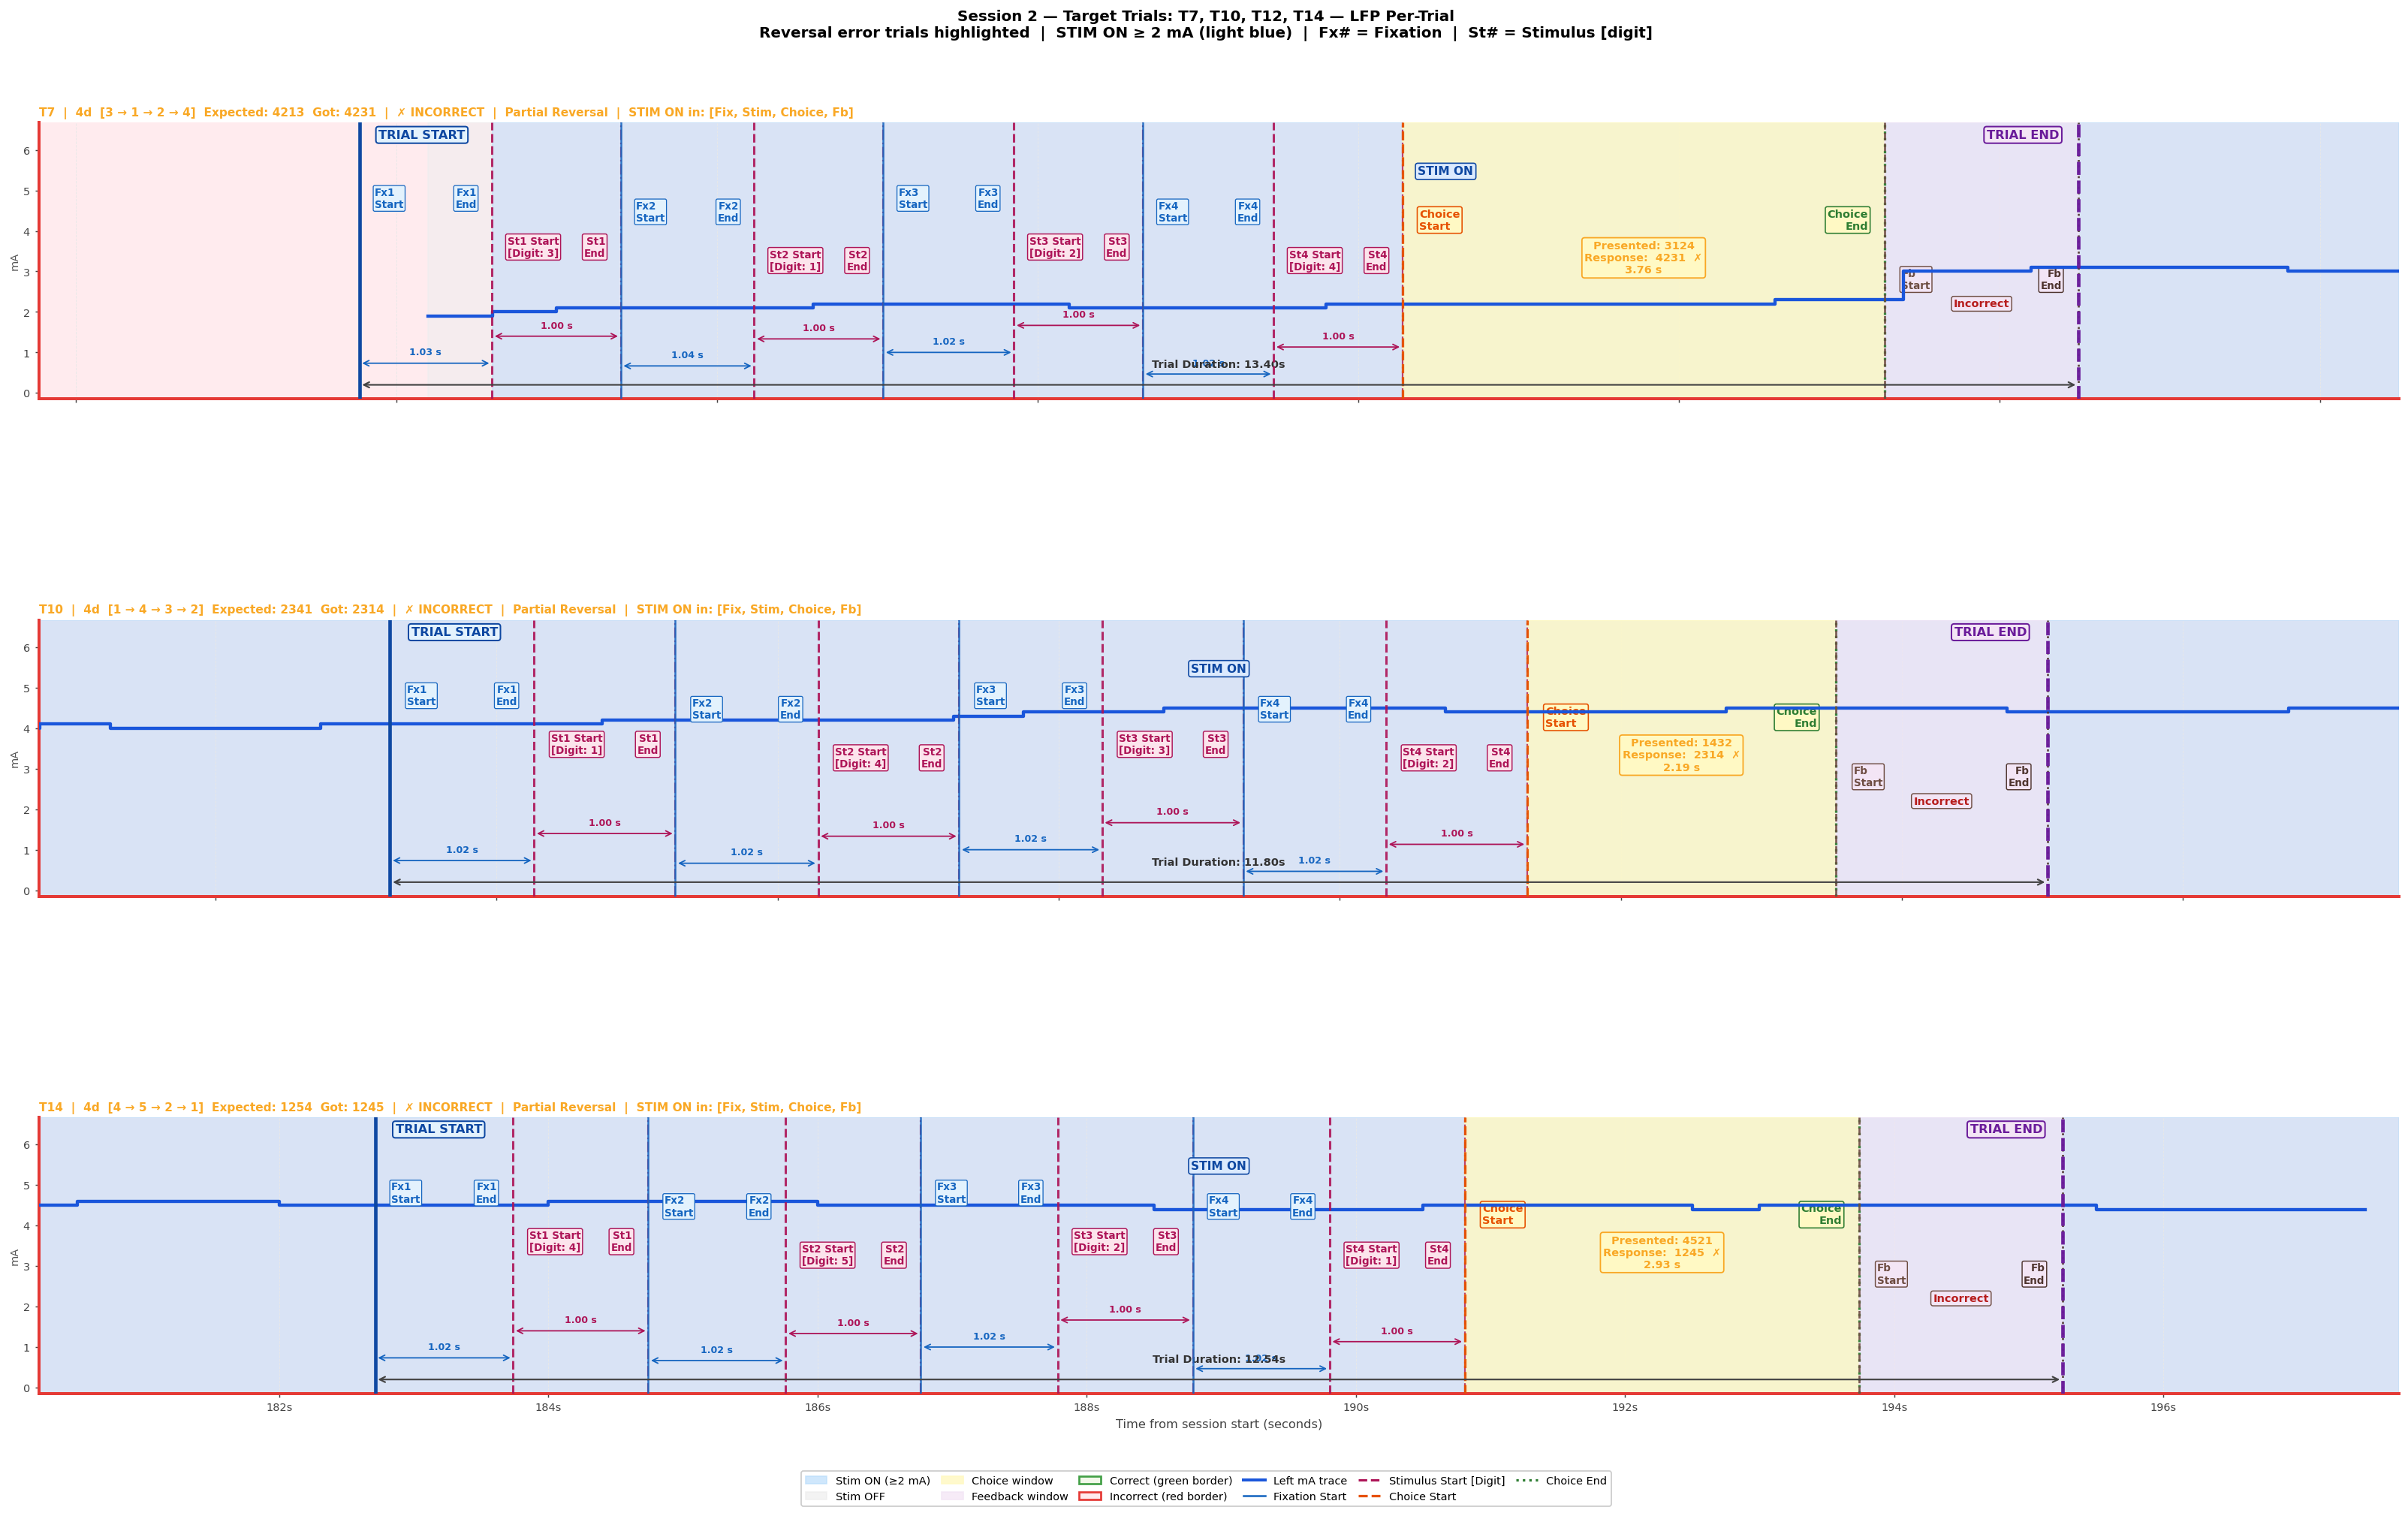

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\lfp_all_trials_part1.png


In [8]:
def plot_lfp_trials(trials, ticks_rel, mAs, ymax, sess_label, out_dir,
                    filter_etypes=None, max_per_fig=5):
    """
    Paginated per-trial LFP plots.
    filter_etypes: if provided, only plot trials with those error types.
    """
    if filter_etypes:
        plot_trials = [t for t in trials if t['error_type'] in filter_etypes]
        tag = 'reversal_errors'
    else:
        plot_trials = trials
        tag = 'all_trials'

    if not plot_trials:
        print(f'No trials to plot for {sess_label} ({filter_etypes})')
        return

    # Sort: reversal errors first, then by trial number
    eo = {e:i for i,e in enumerate(ERROR_ORDER)}
    plot_trials = sorted(plot_trials, key=lambda t: (eo.get(t['error_type'],99), t['num']))

    pages = [plot_trials[i:i+max_per_fig]
             for i in range(0, len(plot_trials), max_per_fig)]

    for pi, page in enumerate(pages):
        n = len(page)
        row_h = 4.5
        fig, axes = plt.subplots(n, 1, figsize=(26, n*row_h+2.0),
                                 facecolor='white',
                                 gridspec_kw=dict(hspace=0.80,
                                                  left=0.04, right=0.97,
                                                  top=0.92, bottom=0.08))
        if n == 1: axes = [axes]

        for ri, t in enumerate(page):
            draw_trial_row(axes[ri], t, ticks_rel, mAs, ymax, is_last=(ri==n-1))

        part = f' (Part {pi+1}/{len(pages)})' if len(pages)>1 else ''
        fig.suptitle(
            f'{sess_label} — LFP Per-Trial{part}\n'
            f'Reversal error trials highlighted  |  '
            f'STIM ON ≥ {STIM_THRESHOLD:.0f} mA (light blue)  |  '
            f'Fx# = Fixation  |  St# = Stimulus [digit]',
            fontsize=11, fontweight='bold', y=0.995)

        fig.legend(handles=LEG_HANDLES, loc='lower center', ncol=6,
                   fontsize=8, framealpha=0.97, facecolor='white', edgecolor='#ccc',
                   bbox_to_anchor=(0.50, 0.002), columnspacing=1.0, handlelength=2.0)

        fname = out_dir / f'lfp_{tag}_part{pi+1}.png'
        fig.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
        plt.show()
        plt.close(fig)
        print(f'Saved → {fname}')


# Session 2 — target trials only (T7, T10, T12, T14)
plot_lfp_trials(trials_s2, tr_s2, mA_s2, ymax_s2,
                'Session 2 — Target Trials: T7, T10, T12, T14', OUT_DIR_S2)

## Cell 8 — Plot: Per-Trial LFP — Session 3

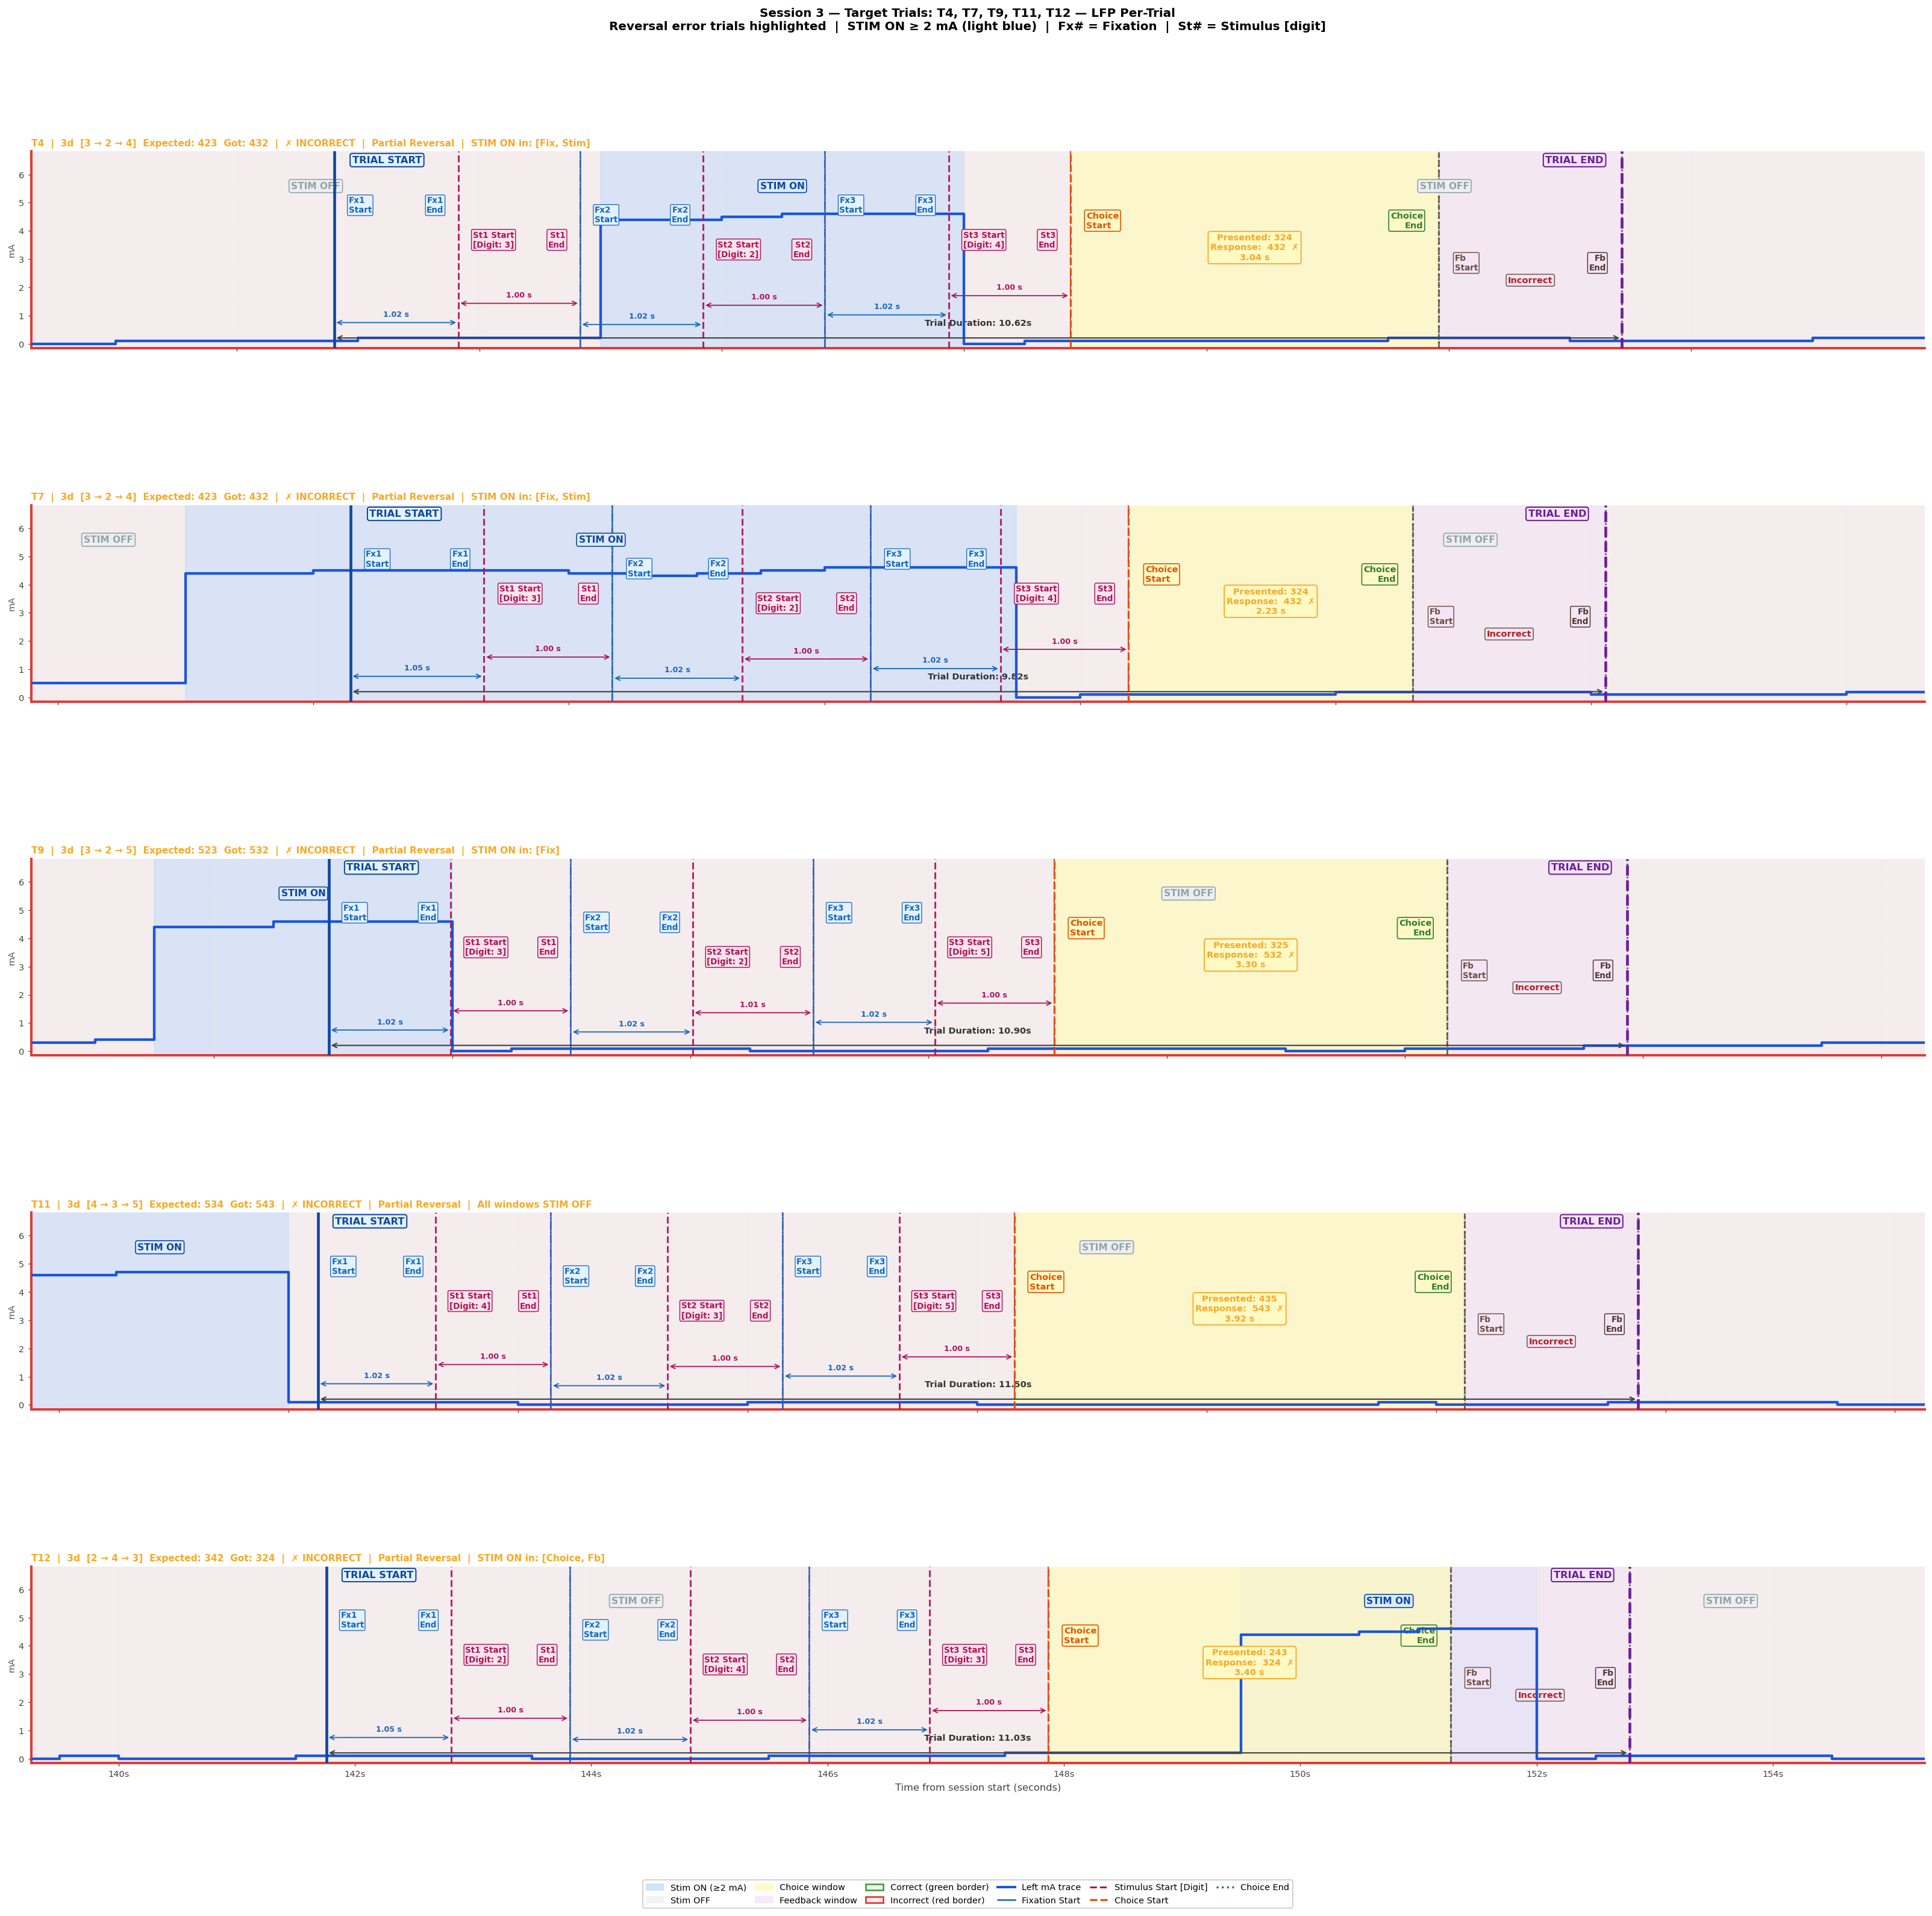

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\lfp_all_trials_part1.png


In [9]:
plot_lfp_trials(trials_s3, tr_s3, mA_s3, ymax_s3,
                'Session 3 — Target Trials: T4, T7, T9, T11, T12', OUT_DIR_S3)

## Cell 9 — Statistics Functions

Same approach as previous notebooks:
- **p-value**: Fisher's Exact
- **Cohen's d**: pooled on binary 0/1 (each trial = one observation)

In [10]:
def fisher_p(n_corr_a, n_a, n_corr_b, n_b):
    if n_a==0 or n_b==0: return np.nan
    _, p = stats.fisher_exact([[n_corr_a, n_a-n_corr_a],
                                [n_corr_b, n_b-n_corr_b]])
    return float(p)


def cohens_d(a, b):
    """Pooled Cohen's d on binary arrays (ddof=1)."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a)<2 or len(b)<2: return np.nan
    pooled = np.sqrt(((len(a)-1)*np.var(a,ddof=1) +
                      (len(b)-1)*np.var(b,ddof=1)) / (len(a)+len(b)-2))
    return float((np.mean(a)-np.mean(b))/pooled) if pooled>0 else np.nan


def d_label(d):
    if np.isnan(d): return 'N/A'
    v = abs(d)
    if v>=0.8: return 'large'
    if v>=0.5: return 'medium'
    if v>=0.2: return 'small'
    return 'negligible'


def sig_stars(p):
    if np.isnan(p): return ''
    if p<0.001: return '***'
    if p<0.01:  return '**'
    if p<0.05:  return '*'
    return 'ns'


print('Stats functions defined.')

Stats functions defined.


## Cell 10 — Core Analysis: PARTIAL REVERSAL × Stim ON/OFF

**Question:** Among PARTIAL REVERSAL trials, how many had STIM ON vs STIM OFF  
in each window? Compare with correct trials.

In [11]:
for sess_label, df in [
    ('Session 2 (T7, T10, T14)',          df_s2),
    ('Session 3 (T4, T7, T9, T11, T12)', df_s3),
    ('Combined (8 PARTIAL trials)',        df_all),
]:
    print(f'\n{"="*72}')
    print(f'  {sess_label}')
    print(f'{"="*72}')

    partial = df[df['error_type'] == 'PARTIAL_REVERSAL']

    print(f'  PARTIAL_REVERSAL trials: {len(partial)}')

    print(f'\n  PARTIAL REVERSAL — stim ON per window:')
    for wc, wl in [('stim_fix','Fixation'), ('stim_stim','Stimulus'),
                   ('stim_choice','Choice'), ('stim_feedback','Feedback'),
                   ('stim_any','ANY window')]:
        n_on  = partial[wc].sum()  if len(partial) else 0
        n_off = len(partial)-n_on  if len(partial) else 0
        pct   = n_on/len(partial)*100 if len(partial) else 0
        print(f'    {wl:<12}: {n_on} ON / {n_off} OFF  ({pct:.0f}% stimulated)')


  Session 2 (T7, T10, T14)
  PARTIAL_REVERSAL trials: 3

  PARTIAL REVERSAL — stim ON per window:
    Fixation    : 3 ON / 0 OFF  (100% stimulated)
    Stimulus    : 3 ON / 0 OFF  (100% stimulated)
    Choice      : 3 ON / 0 OFF  (100% stimulated)
    Feedback    : 3 ON / 0 OFF  (100% stimulated)
    ANY window  : 3 ON / 0 OFF  (100% stimulated)

  Session 3 (T4, T7, T9, T11, T12)
  PARTIAL_REVERSAL trials: 5

  PARTIAL REVERSAL — stim ON per window:
    Fixation    : 3 ON / 2 OFF  (60% stimulated)
    Stimulus    : 2 ON / 3 OFF  (40% stimulated)
    Choice      : 1 ON / 4 OFF  (20% stimulated)
    Feedback    : 1 ON / 4 OFF  (20% stimulated)
    ANY window  : 4 ON / 1 OFF  (80% stimulated)

  Combined (8 PARTIAL trials)
  PARTIAL_REVERSAL trials: 8

  PARTIAL REVERSAL — stim ON per window:
    Fixation    : 6 ON / 2 OFF  (75% stimulated)
    Stimulus    : 5 ON / 3 OFF  (62% stimulated)
    Choice      : 4 ON / 4 OFF  (50% stimulated)
    Feedback    : 4 ON / 4 OFF  (50% stimulated)
 

## Cell 11 — Plot: Reversal Error Count — STIM ON vs OFF

For each session + combined:
grouped bar: x = error type, bars = STIM ON vs OFF count

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\reversal_stim_counts_S2.png


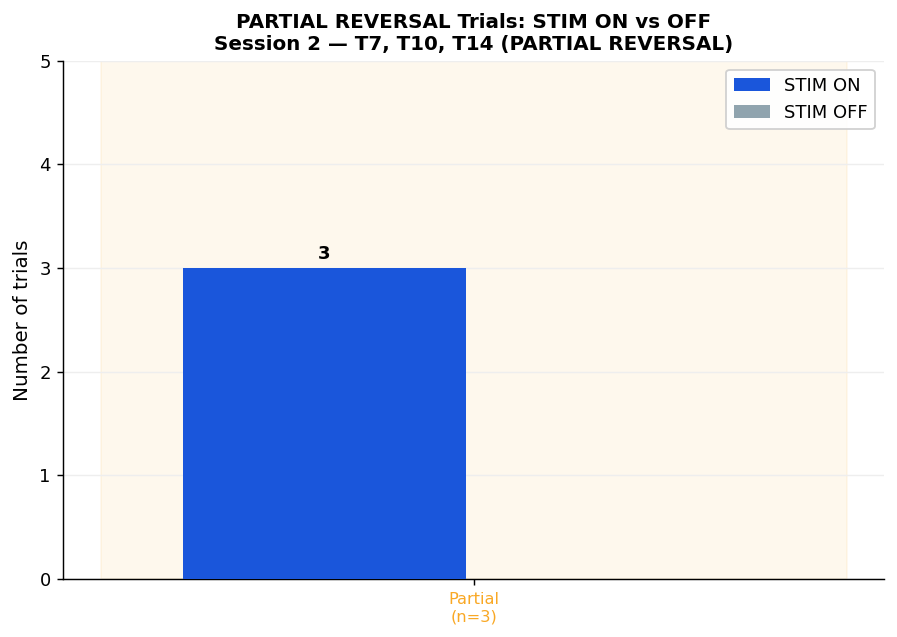

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\reversal_stim_counts_S3.png


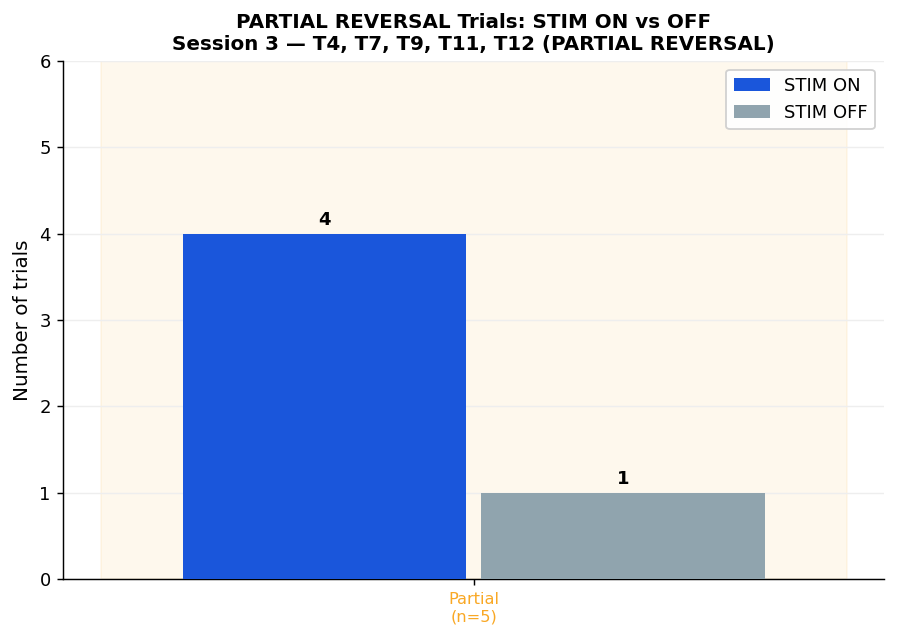

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\reversal_stim_counts_combined.png


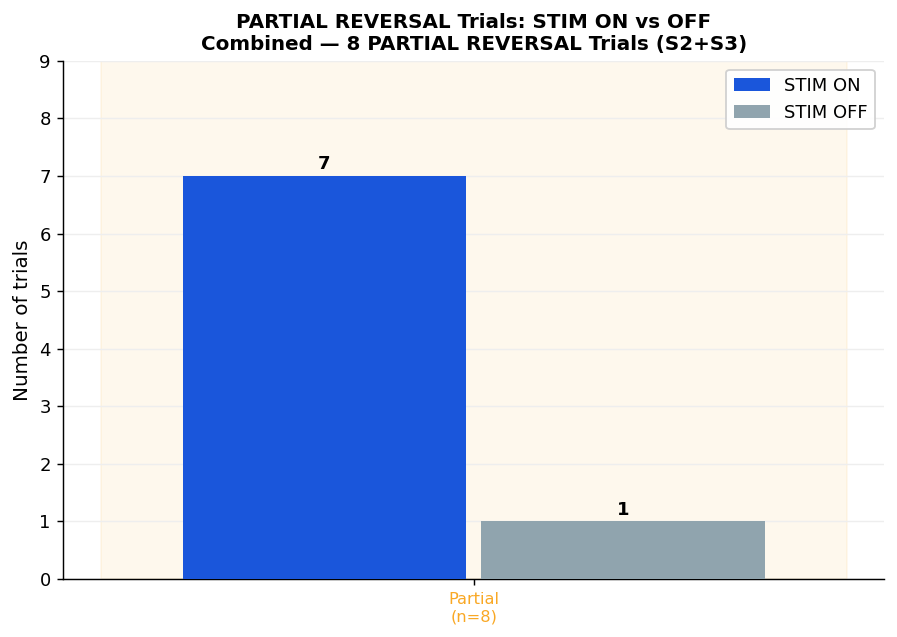

In [12]:
def plot_error_stim_counts(df, sess_label, save_path=None):
    """
    Stacked bars: for each error type, how many trials had STIM ON vs OFF.
    Highlights the reversal error types in red/orange.
    """
    etypes = [e for e in ERROR_ORDER if e in df['error_type'].unique()]

    n_on_list, n_off_list, colors = [], [], []
    for et in etypes:
        sub    = df[df['error_type']==et]
        n_on   = int(sub['stim_any'].sum())
        n_off  = len(sub) - n_on
        n_on_list.append(n_on)
        n_off_list.append(n_off)
        colors.append(ERROR_META.get(et, dict(color='#555'))['color'])

    xs = np.arange(len(etypes))
    fig, ax = plt.subplots(figsize=(max(7, len(etypes)*2), 5), facecolor='white')

    b1 = ax.bar(xs-0.2, n_on_list,  width=0.38, color=C_ON,  label='STIM ON',  zorder=3)
    b2 = ax.bar(xs+0.2, n_off_list, width=0.38, color=C_OFF, label='STIM OFF', zorder=3)

    for bar, n in zip(list(b1)+list(b2), n_on_list+n_off_list):
        if n > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                    str(n), ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Highlight reversal error columns
    for xi, et in enumerate(etypes):
        if et in REVERSAL_ERRORS:
            ax.axvspan(xi-0.5, xi+0.5, color=colors[xi], alpha=0.08, zorder=0)

    xlabels = [f"{ERROR_META.get(e,dict(short=e))['short']}\n(n={len(df[df['error_type']==e])})"
               for e in etypes]
    ax.set_xticks(xs)
    ax.set_xticklabels(xlabels, fontsize=9)
    for xt, c in zip(ax.get_xticklabels(), colors): xt.set_color(c)

    ax.set_ylabel('Number of trials', fontsize=11)
    ax.set_ylim(0, max(max(n_on_list+n_off_list)+2, 5))
    ax.yaxis.grid(True, color='#eee', zorder=0); ax.set_axisbelow(True)
    ax.set_facecolor('white')
    ax.legend(fontsize=10, framealpha=0.9)
    ax.set_title(f'PARTIAL REVERSAL Trials: STIM ON vs OFF\n{sess_label}',
                 fontsize=11, fontweight='bold')
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight'); print(f'Saved → {save_path}')
    plt.show(); plt.close(fig)


plot_error_stim_counts(df_s2,  'Session 2 — T7, T10, T14 (PARTIAL REVERSAL)',
    save_path=OUT_DIR_S2 / 'reversal_stim_counts_S2.png')
plot_error_stim_counts(df_s3,  'Session 3 — T4, T7, T9, T11, T12 (PARTIAL REVERSAL)',
    save_path=OUT_DIR_S3 / 'reversal_stim_counts_S3.png')
plot_error_stim_counts(df_all, 'Combined — 8 PARTIAL REVERSAL Trials (S2+S3)',
    save_path=COMBINED_DIR / 'reversal_stim_counts_combined.png')

## Cell 11b — Stim ON vs Stim OFF Within-Window Comparison

Fix 1 and Fix 2 (etc.) are treated as **the same window within the same trial**.
For each sub-window observation we record the stim_frac, then split:
- **Stim-ON** (frac >= 0.5) vs **Stim-OFF** (frac < 0.5)

Metrics: p-value (Fisher's Exact), Cohen's d, effect size.

In [13]:
# ── collect per-sub-window stim observations across ALL trials ────────────────
def collect_window_obs(all_trials_list, window):
    obs = []   # (stim_frac, acc, error_type)
    for t in all_trials_list:
        if window == 'Fixation':
            for f in t['stim_fix_fracs']:
                if not np.isnan(f): obs.append((f, t['acc'], t['error_type']))
        elif window == 'Stimulus':
            for f in t['stim_stim_fracs']:
                if not np.isnan(f): obs.append((f, t['acc'], t['error_type']))
        elif window == 'Choice':
            f = t['stim_ch_frac']
            if not np.isnan(f): obs.append((f, t['acc'], t['error_type']))
        elif window == 'Feedback':
            f = t['stim_fb_frac']
            if not np.isnan(f): obs.append((f, t['acc'], t['error_type']))
    return obs


def within_window_stim_comparison(all_trials_list, label, threshold=0.5):
    rows = []
    for window in WINDOW_ORDER:
        obs = collect_window_obs(all_trials_list, window)
        if not obs:
            continue
        fracs  = np.array([o[0] for o in obs])
        accs   = np.array([o[1] for o in obs], dtype=float)
        etypes = [o[2] for o in obs]

        on_mask  = fracs >= threshold
        off_mask = ~on_mask
        acc_on   = accs[on_mask]
        acc_off  = accs[off_mask]
        n_on, n_off = on_mask.sum(), off_mask.sum()

        # Fisher's exact on accuracy counts
        if n_on > 0 and n_off > 0:
            _, p_fish = stats.fisher_exact([
                [int(acc_on.sum()),  int(n_on  - acc_on.sum())],
                [int(acc_off.sum()), int(n_off - acc_off.sum())]
            ])
            p_fish = float(p_fish)
        else:
            p_fish = np.nan

        # Mann-Whitney U on stim fracs
        if n_on >= 2 and n_off >= 2:
            _, p_mwu = stats.mannwhitneyu(fracs[on_mask], fracs[off_mask],
                                           alternative='two-sided')
            p_mwu = float(p_mwu)
        else:
            p_mwu = np.nan

        d = cohens_d(acc_on, acc_off)

        def etype_pct(mask):
            sub = [etypes[j] for j in range(len(etypes)) if mask[j]]
            if not sub: return 'none'
            return ', '.join(f"{e}:{sub.count(e)}" for e in ERROR_ORDER if sub.count(e) > 0)

        rows.append(dict(
            Session      = label,
            Window       = window,
            N_ON_obs     = int(n_on),
            Acc_ON_pct   = f'{acc_on.mean()*100:.0f}%' if n_on > 0 else '-',
            N_OFF_obs    = int(n_off),
            Acc_OFF_pct  = f'{acc_off.mean()*100:.0f}%' if n_off > 0 else '-',
            p_Fisher     = p_fish,
            p_MWU        = p_mwu,
            Stars        = sig_stars(p_fish),
            Cohens_d     = d,
            Effect_Size  = d_label(d),
            ErrTypes_ON  = etype_pct(on_mask),
            ErrTypes_OFF = etype_pct(off_mask),
        ))
    return pd.DataFrame(rows)


def print_within_window_stats(df_stats, label):
    print(f'\n{"="*80}')
    print(f'  Stim ON vs OFF within each window -- {label}')
    print(f'  (Fix1+Fix2 pooled as Fixation; Stim1+Stim2 pooled as Stimulus)')
    print(f'{"="*80}')
    print(f'  {"Window":<12} {"N_ON":>5} {"Acc_ON":>7} {"N_OFF":>6} {"Acc_OFF":>8}  {"p(Fisher)":>10}  {"Stars":>4}  {"d":>7}  Effect')
    print(f'  {"-"*78}')
    for _, r in df_stats.iterrows():
        pf = f'{r["p_Fisher"]:.4f}' if not np.isnan(r["p_Fisher"]) else ' N/A  '
        ds = f'{r["Cohens_d"]:+.3f}'  if not np.isnan(r["Cohens_d"]) else '  N/A'
        print(f'  {r["Window"]:<12} {r["N_ON_obs"]:>5} {r["Acc_ON_pct"]:>7} {r["N_OFF_obs"]:>6} '
              f'{r["Acc_OFF_pct"]:>8}  p={pf}  {r["Stars"]:>4}  d={ds}  ({r["Effect_Size"]})')


# Use PARTIAL REVERSAL target trials only
# trials_s2 and trials_s3 already contain only the target (PARTIAL) trials
all_trials_s2_partial = trials_s2
all_trials_s3_partial = trials_s3
all_trials_combined   = all_trials_s2_partial + all_trials_s3_partial

ws_s2  = within_window_stim_comparison(all_trials_s2_partial, 'Session 2 — T7,T10,T14 (PARTIAL)')
ws_s3  = within_window_stim_comparison(all_trials_s3_partial, 'Session 3 — T4,T7,T9,T11,T12 (PARTIAL)')
ws_all = within_window_stim_comparison(all_trials_combined,   'Combined — 8 PARTIAL trials')

print_within_window_stats(ws_s2,  'Session 2 PARTIAL trials')
print_within_window_stats(ws_s3,  'Session 3 PARTIAL trials')
print_within_window_stats(ws_all, 'Combined PARTIAL trials')


  Stim ON vs OFF within each window -- Session 2 PARTIAL trials
  (Fix1+Fix2 pooled as Fixation; Stim1+Stim2 pooled as Stimulus)
  Window        N_ON  Acc_ON  N_OFF  Acc_OFF   p(Fisher)  Stars        d  Effect
  ------------------------------------------------------------------------------
  Fixation        11      0%      1       0%  p=1.0000    ns  d=  N/A  (N/A)
  Stimulus        12      0%      0        -  p= N/A          d=  N/A  (N/A)
  Choice           3      0%      0        -  p= N/A          d=  N/A  (N/A)
  Feedback         3      0%      0        -  p= N/A          d=  N/A  (N/A)

  Stim ON vs OFF within each window -- Session 3 PARTIAL trials
  (Fix1+Fix2 pooled as Fixation; Stim1+Stim2 pooled as Stimulus)
  Window        N_ON  Acc_ON  N_OFF  Acc_OFF   p(Fisher)  Stars        d  Effect
  ------------------------------------------------------------------------------
  Fixation         6      0%      9       0%  p=1.0000    ns  d=  N/A  (N/A)
  Stimulus         3      0%   

## Cell 11c — Plot: Stim ON vs OFF Within Each Window

Bars = % Correct in Stim-ON observations vs Stim-OFF observations.
Bracket shows Fisher p + Cohen d. Fix1 & Fix2 pooled as Fixation, etc.

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\partial_stim_on_vs_off_S2.png


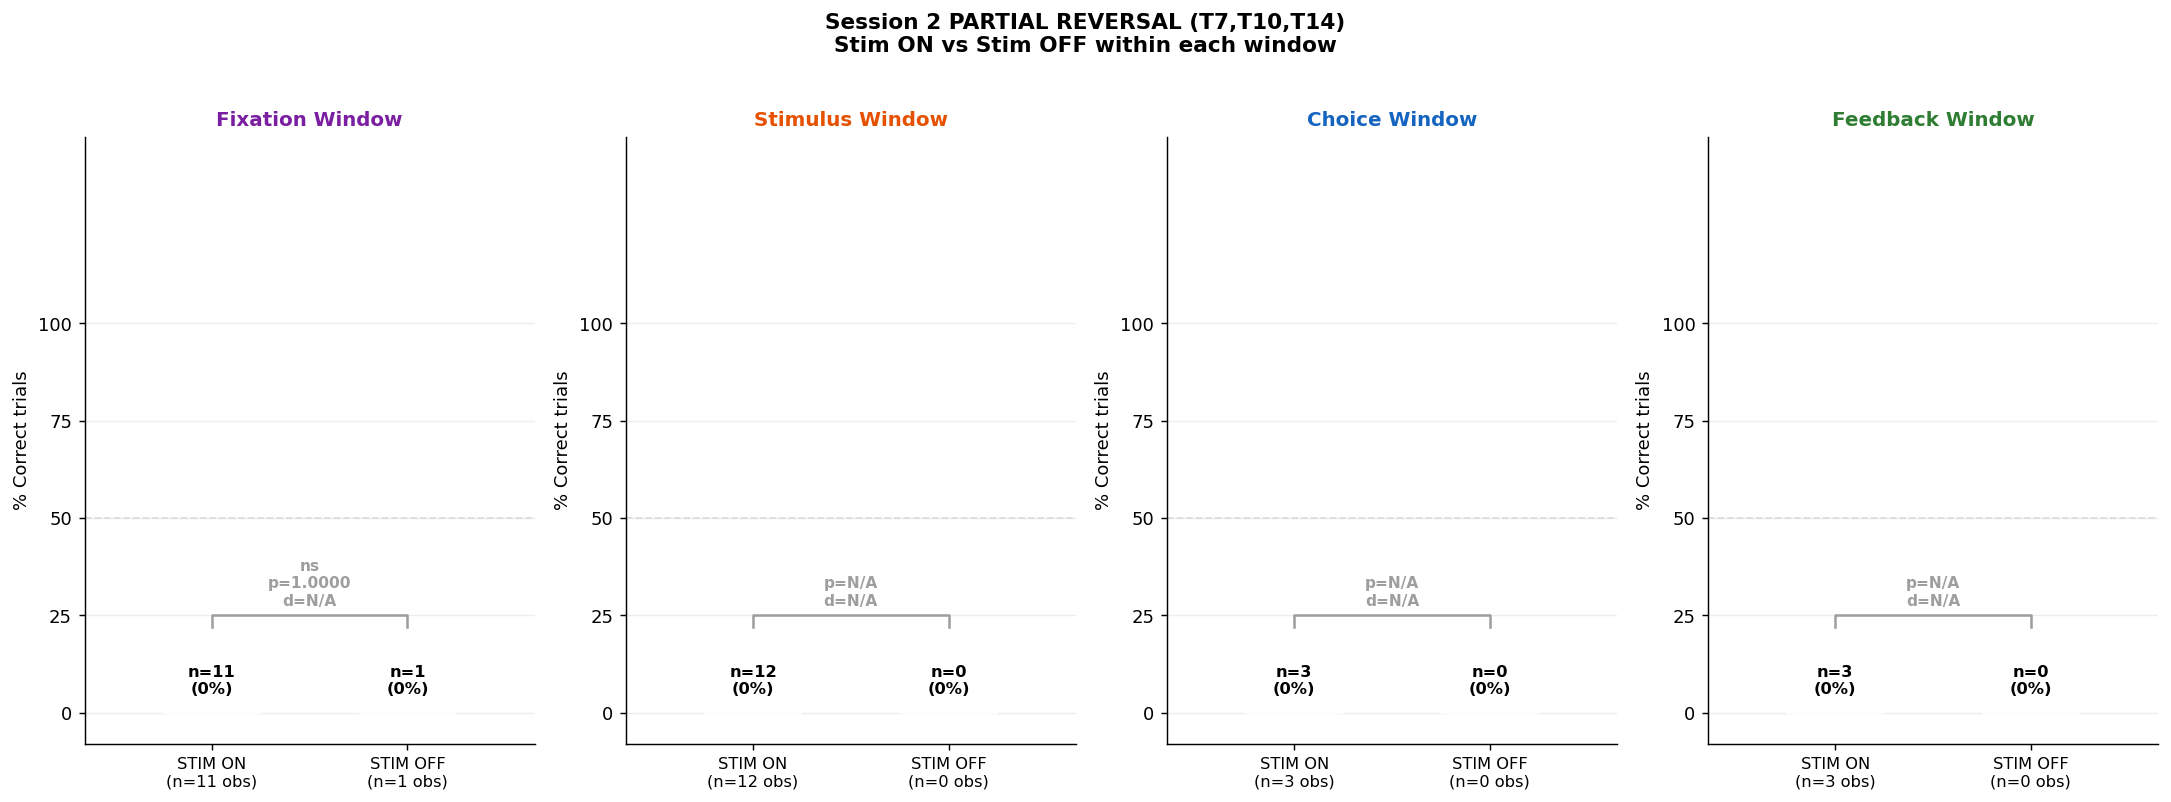

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\partial_stim_on_vs_off_S3.png


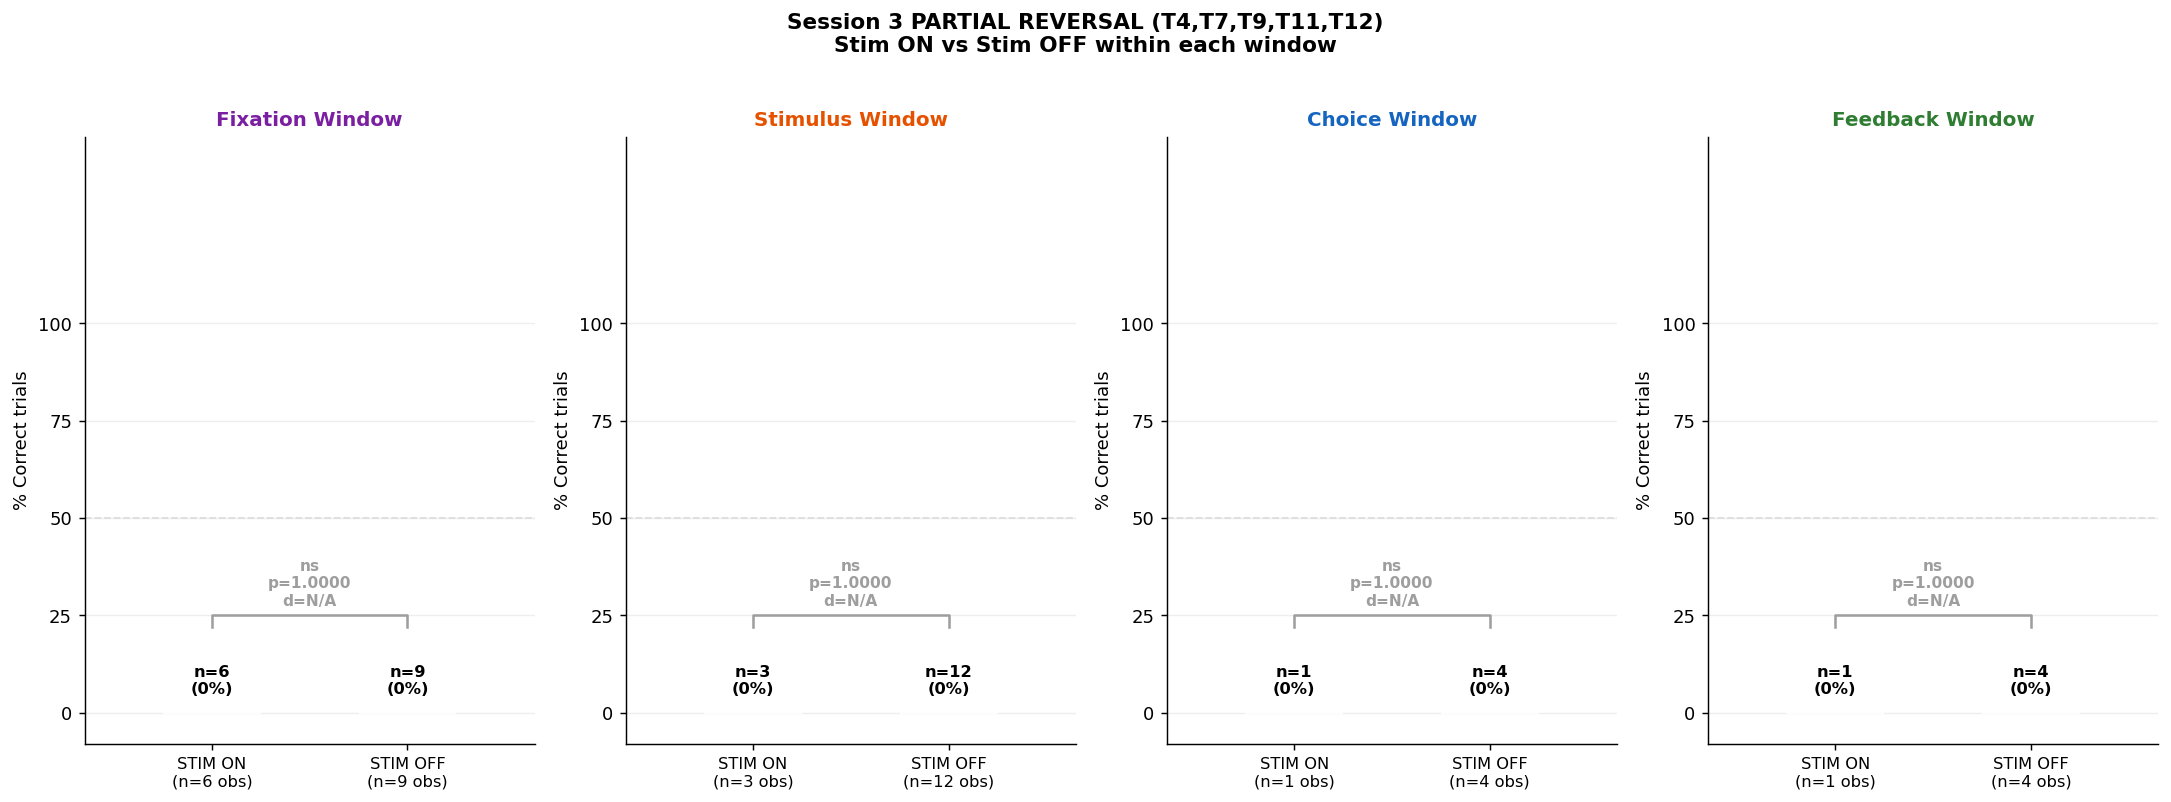

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\partial_stim_on_vs_off_combined.png


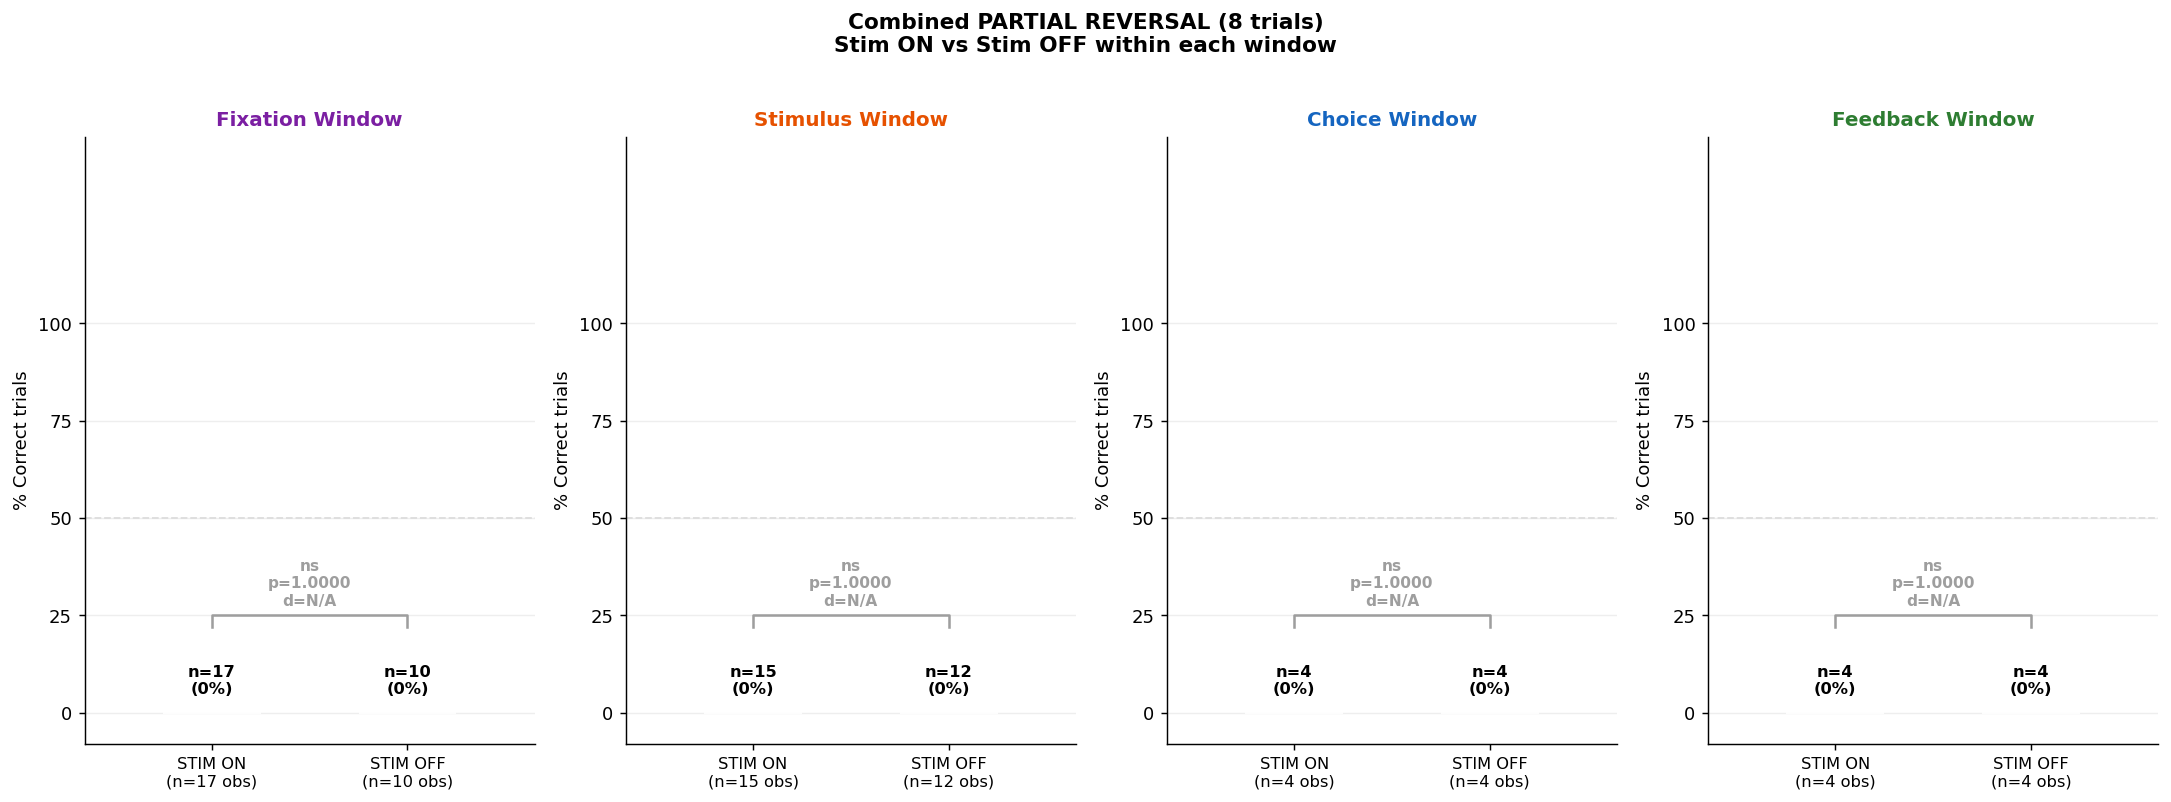

In [14]:
def plot_within_window_comparison(ws_df, title, save_path=None):
    windows = ws_df['Window'].tolist()
    n = len(windows)
    fig, axes = plt.subplots(1, n, figsize=(n * 4.2, 6.0), facecolor='white')
    if n == 1: axes = [axes]

    for ax, (_, row) in zip(axes, ws_df.iterrows()):
        wc = WINDOW_COLORS.get(row['Window'], '#555')

        def parse_pct(s):
            if s in ('-', ''): return 0.0
            return float(s.rstrip('%'))

        pct_on  = parse_pct(row['Acc_ON_pct'])
        pct_off = parse_pct(row['Acc_OFF_pct'])

        ax.bar([0, 1], [pct_on, pct_off], width=0.50,
               color=[C_ON, C_OFF], zorder=3, edgecolor='white')

        for xi, n_obs, pct in [(0, row['N_ON_obs'], pct_on),
                                (1, row['N_OFF_obs'], pct_off)]:
            ax.text(xi, pct + 4, f'n={n_obs}\n({pct:.0f}%)',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

        p_v = row['p_Fisher']
        d_v = row['Cohens_d']
        y_top = min(max(pct_on, pct_off) + 22, 118)
        pad = 3
        bcol = '#D32F2F' if (not np.isnan(p_v) and p_v < 0.05) else '#9E9E9E'
        ax.plot([0,0,1,1], [y_top, y_top+pad, y_top+pad, y_top], lw=1.4, color=bcol, zorder=6)
        p_s = f'p={p_v:.4f}' if not np.isnan(p_v) else 'p=N/A'
        d_s = f'd={d_v:+.2f} ({d_label(d_v)})' if not np.isnan(d_v) else 'd=N/A'
        ax.text(0.5, y_top + pad*1.6, f'{sig_stars(p_v)}\n{p_s}\n{d_s}',
                ha='center', va='bottom', fontsize=8.5, color=bcol, fontweight='bold', zorder=7)

        ax.set_xlim(-0.65, 1.65); ax.set_ylim(-8, 148)
        ax.set_xticks([0, 1])
        ax.set_xticklabels([f'STIM ON\n(n={row["N_ON_obs"]} obs)',
                             f'STIM OFF\n(n={row["N_OFF_obs"]} obs)'], fontsize=9)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.set_ylabel('% Correct trials', fontsize=10)
        ax.axhline(50, color='#ddd', lw=1, ls='--', zorder=1)
        ax.yaxis.grid(True, color='#eee', zorder=0); ax.set_axisbelow(True)
        ax.set_facecolor('white')
        ax.set_title(f'{row["Window"]} Window', fontsize=11, fontweight='bold', color=wc)

    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.02)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight'); print(f'Saved -> {save_path}')
    plt.show(); plt.close(fig)


plot_within_window_comparison(ws_s2,
    title='Session 2 PARTIAL REVERSAL (T7,T10,T14)\nStim ON vs Stim OFF within each window',
    save_path=OUT_DIR_S2 / 'partial_stim_on_vs_off_S2.png')

plot_within_window_comparison(ws_s3,
    title='Session 3 PARTIAL REVERSAL (T4,T7,T9,T11,T12)\nStim ON vs Stim OFF within each window',
    save_path=OUT_DIR_S3 / 'partial_stim_on_vs_off_S3.png')

plot_within_window_comparison(ws_all,
    title='Combined PARTIAL REVERSAL (8 trials)\nStim ON vs Stim OFF within each window',
    save_path=COMBINED_DIR / 'partial_stim_on_vs_off_combined.png')

## Cell 11d — Export Within-Window Stats to CSV

In [15]:
combined_ws = pd.concat([ws_s2, ws_s3, ws_all], ignore_index=True)

def fmt_floats(df):
    df = df.copy()
    for col in ['p_Fisher', 'p_MWU', 'Cohens_d']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f'{x:.4f}' if not (isinstance(x, float) and np.isnan(x)) else 'N/A')
    return df

display(fmt_floats(combined_ws))
out_csv = COMBINED_DIR / 'within_window_stim_on_vs_off_stats.csv'
combined_ws.to_csv(out_csv, index=False)
print(f'Saved -> {out_csv}')

,Session,Window,N_ON_obs,Acc_ON_pct,N_OFF_obs,Acc_OFF_pct,p_Fisher,p_MWU,Stars,Cohens_d,Effect_Size,ErrTypes_ON,ErrTypes_OFF
0,"Session 2 — T7,T10,T14 (PARTIAL)",Fixation,11,0%,1,0%,1.0000,N/A,ns,N/A,N/A,PARTIAL_REVERSAL:11,PARTIAL_REVERSAL:1
1,"Session 2 — T7,T10,T14 (PARTIAL)",Stimulus,12,0%,0,-,N/A,N/A,,N/A,N/A,PARTIAL_REVERSAL:12,none
2,"Session 2 — T7,T10,T14 (PARTIAL)",Choice,3,0%,0,-,N/A,N/A,,N/A,N/A,PARTIAL_REVERSAL:3,none
3,"Session 2 — T7,T10,T14 (PARTIAL)",Feedback,3,0%,0,-,N/A,N/A,,N/A,N/A,PARTIAL_REVERSAL:3,none
4,"Session 3 — T4,T7,T9,T11,T12 (PARTIAL)",Fixation,6,0%,9,0%,1.0000,0.0002,ns,N/A,N/A,PARTIAL_REVERSAL:6,PARTIAL_REVERSAL:9
5,"Session 3 — T4,T7,T9,T11,T12 (PARTIAL)",Stimulus,3,0%,12,0%,1.0000,0.0003,ns,N/A,N/A,PARTIAL_REVERSAL:3,PARTIAL_REVERSAL:12
6,"Session 3 — T4,T7,T9,T11,T12 (PARTIAL)",Choice,1,0%,4,0%,1.0000,N/A,ns,N/A,N/A,PARTIAL_REVERSAL:1,PARTIAL_REVERSAL:4
7,"Session 3 — T4,T7,T9,T11,T12 (PARTIAL)",Feedback,1,0%,4,0%,1.0000,N/A,ns,N/A,N/A,PARTIAL_REVERSAL:1,PARTIAL_REVERSAL:4
8,Combined — 8 PARTIAL trials,Fixation,17,0%,10,0%,1.0000,0.0000,ns,N/A,N/A,PARTIAL_REVERSAL:17,PARTIAL_REVERSAL:10
9,Combined — 8 PARTIAL trials,Stimulus,15,0%,12,0%,1.0000,0.0000,ns,N/A,N/A,PARTIAL_REVERSAL:15,PARTIAL_REVERSAL:12


Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\within_window_stim_on_vs_off_stats.csv


## Cell 12 — Plot: Window-Level Stats (p-value + Cohen's d)

For each window × session:
Compare **PARTIAL REVERSAL trials** (STIM ON vs STIM OFF) — is STIM ON associated with reversal failure?

Also compare **reversal-error vs correct** — is being in the reversal-error group associated with more stimulation?

In [16]:
def window_stats_comparison(df, group_a_mask, group_b_mask, label_a, label_b):
    """
    For each window: compare group_a vs group_b on stim_on (binary).
    Returns DataFrame of stats.
    """
    rows = []
    for wc, wl in [('stim_fix','Fixation'),('stim_stim','Stimulus'),
                   ('stim_choice','Choice'),('stim_feedback','Feedback')]:
        a = df[group_a_mask][wc].astype(float).values
        b = df[group_b_mask][wc].astype(float).values

        n_on_a  = int(a.sum());  n_a = len(a)
        n_on_b  = int(b.sum());  n_b = len(b)
        acc_a   = a.mean() if n_a>0 else np.nan
        acc_b   = b.mean() if n_b>0 else np.nan
        p       = fisher_p(n_on_a, n_a, n_on_b, n_b)
        d       = cohens_d(a, b)

        rows.append(dict(
            Window=wl, label_a=label_a, label_b=label_b,
            n_a=n_a, n_on_a=n_on_a, pct_a=f'{acc_a*100:.0f}%' if not np.isnan(acc_a) else '—',
            n_b=n_b, n_on_b=n_on_b, pct_b=f'{acc_b*100:.0f}%' if not np.isnan(acc_b) else '—',
            p=p, d=d,
            stars=sig_stars(p), effect=d_label(d),
        ))
    return pd.DataFrame(rows)


def plot_window_stats(stats_df, title, save_path=None):
    """
    4-subplot bar chart: one per window.
    Bars = % stim ON in group A (reversal error) vs group B (correct).
    Bracket shows p + Cohen's d.
    """
    windows = stats_df['Window'].tolist()
    n = len(windows)
    fig, axes = plt.subplots(1, n, figsize=(n*4.0, 5.8), facecolor='white')
    if n==1: axes=[axes]

    for ax, (_, row) in zip(axes, stats_df.iterrows()):
        wc = WINDOW_COLORS.get(row['Window'], '#555')
        pct_a = row['n_on_a']/row['n_a']*100 if row['n_a']>0 else 0
        pct_b = row['n_on_b']/row['n_b']*100 if row['n_b']>0 else 0

        # Colours: reversal error = red-tinted, correct = green-tinted
        col_a = '#E53935'   # reversal error group
        col_b = '#43A047'   # correct group

        ax.bar([0,1], [pct_a, pct_b], width=0.50,
               color=[col_a, col_b], zorder=3, edgecolor='white')

        # Dots
        rng = np.random.default_rng(42)
        for xi, n_on, n_tot in [(0,row['n_on_a'],row['n_a']),
                                  (1,row['n_on_b'],row['n_b'])]:
            scores = np.array([1]*n_on + [0]*(n_tot-n_on), dtype=float)
            jitter = rng.uniform(-0.08, 0.08, size=len(scores))
            ax.scatter(xi+jitter, scores*100, color='black', s=24, zorder=5, alpha=0.55)

        # Count labels
        for xi, n_on, n_tot, pct in [(0,row['n_on_a'],row['n_a'],pct_a),
                                      (1,row['n_on_b'],row['n_b'],pct_b)]:
            ax.text(xi, pct+5, f'{n_on}/{n_tot}\n({pct:.0f}%)',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

        # Bracket
        y_top = max(pct_a, pct_b)+18; y_top = min(y_top,116)
        pad = 3
        p_v, d_v = row['p'], row['d']
        bcol = '#D32F2F' if (not np.isnan(p_v) and p_v<0.05) else '#9E9E9E'
        ax.plot([0,0,1,1],[y_top,y_top+pad,y_top+pad,y_top], lw=1.4, color=bcol, zorder=6)
        p_s = f'p={p_v:.4f}' if not np.isnan(p_v) else 'p=N/A'
        d_s = f'd={d_v:+.2f} ({d_label(d_v)})' if not np.isnan(d_v) else 'd=N/A'
        ax.text(0.5, y_top+pad*1.5, f'{sig_stars(p_v)}\n{p_s}\n{d_s}',
                ha='center', va='bottom', fontsize=8.5,
                color=bcol, fontweight='bold', zorder=7)

        ax.set_xlim(-0.65,1.65); ax.set_ylim(-8,148)
        ax.set_xticks([0,1])
        ax.set_xticklabels([f'{row["label_a"]}\n(n={row["n_a"]})',
                             f'{row["label_b"]}\n(n={row["n_b"]})'], fontsize=9)
        ax.set_yticks([0,25,50,75,100])
        ax.set_ylabel('% trials with STIM ON', fontsize=10)
        ax.axhline(50, color='#ddd', lw=1, ls='--', zorder=1)
        ax.yaxis.grid(True, color='#eee', zorder=0); ax.set_axisbelow(True)
        ax.set_facecolor('white')
        ax.set_title(f'{row["Window"]} Window', fontsize=11,
                     fontweight='bold', color=wc)

    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.01)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight'); print(f'Saved → {save_path}')
    plt.show(); plt.close(fig)


print('Stats + plot functions defined.')

Stats + plot functions defined.


## Cell 13 — Run Stats: Reversal Error vs Correct, per window

Session 2: 14 trials
  PARTIAL_REVERSAL: 3
  CORRECT: 6
Session 3: 14 trials
  PARTIAL_REVERSAL: 5
  CORRECT: 8
Session 2: 14 trials
  PARTIAL_REVERSAL: 3
  CORRECT: 6
Session 3: 14 trials
  PARTIAL_REVERSAL: 5
  CORRECT: 8

  Session 2 (T7,T10,T14) — PARTIAL REVERSAL vs Other Trials: % STIM ON per window
  PARTIAL (n=3) vs Other (n=11)
  Window        PARTIAL ON   Other ON         p  stars         d  Effect
  ----------------------------------------------------------------------
  Fixation     3/3 (100%)   6/11 (55%)   p=0.2582    ns  d=+0.953  (large)
  Stimulus     3/3 (100%)   6/11 (55%)   p=0.2582    ns  d=+0.953  (large)
  Choice       3/3 (100%)   5/11 (45%)   p=0.2088    ns  d=+1.144  (large)
  Feedback     3/3 (100%)   5/11 (45%)   p=0.2088    ns  d=+1.144  (large)
Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\window_stats_partial_vs_other_2.png


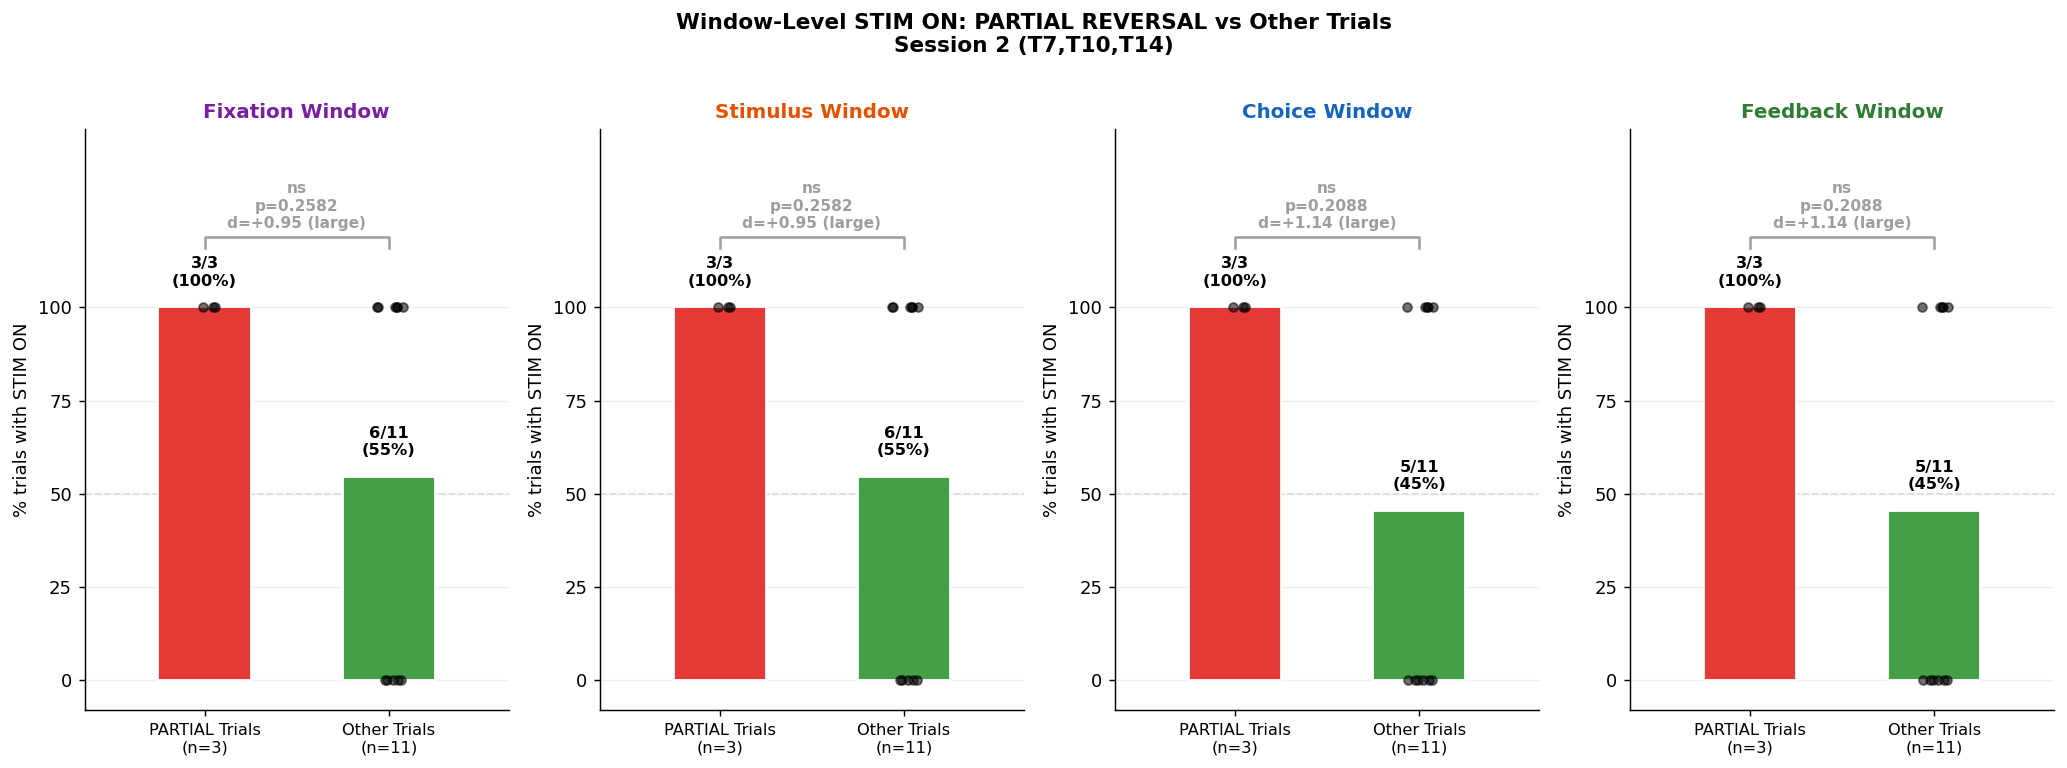


  Session 3 (T4,T7,T9,T11,T12) — PARTIAL REVERSAL vs Other Trials: % STIM ON per window
  PARTIAL (n=5) vs Other (n=9)
  Window        PARTIAL ON   Other ON         p  stars         d  Effect
  ----------------------------------------------------------------------
  Fixation     3/5 (60%)   1/9 (11%)   p=0.0949    ns  d=+1.172  (large)
  Stimulus     2/5 (40%)   2/9 (22%)   p=0.5804    ns  d=+0.371  (small)
  Choice       1/5 (20%)   1/9 (11%)   p=1.0000    ns  d=+0.237  (small)
  Feedback     1/5 (20%)   4/9 (44%)   p=0.5804    ns  d=-0.487  (small)
Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\window_stats_partial_vs_other_3.png


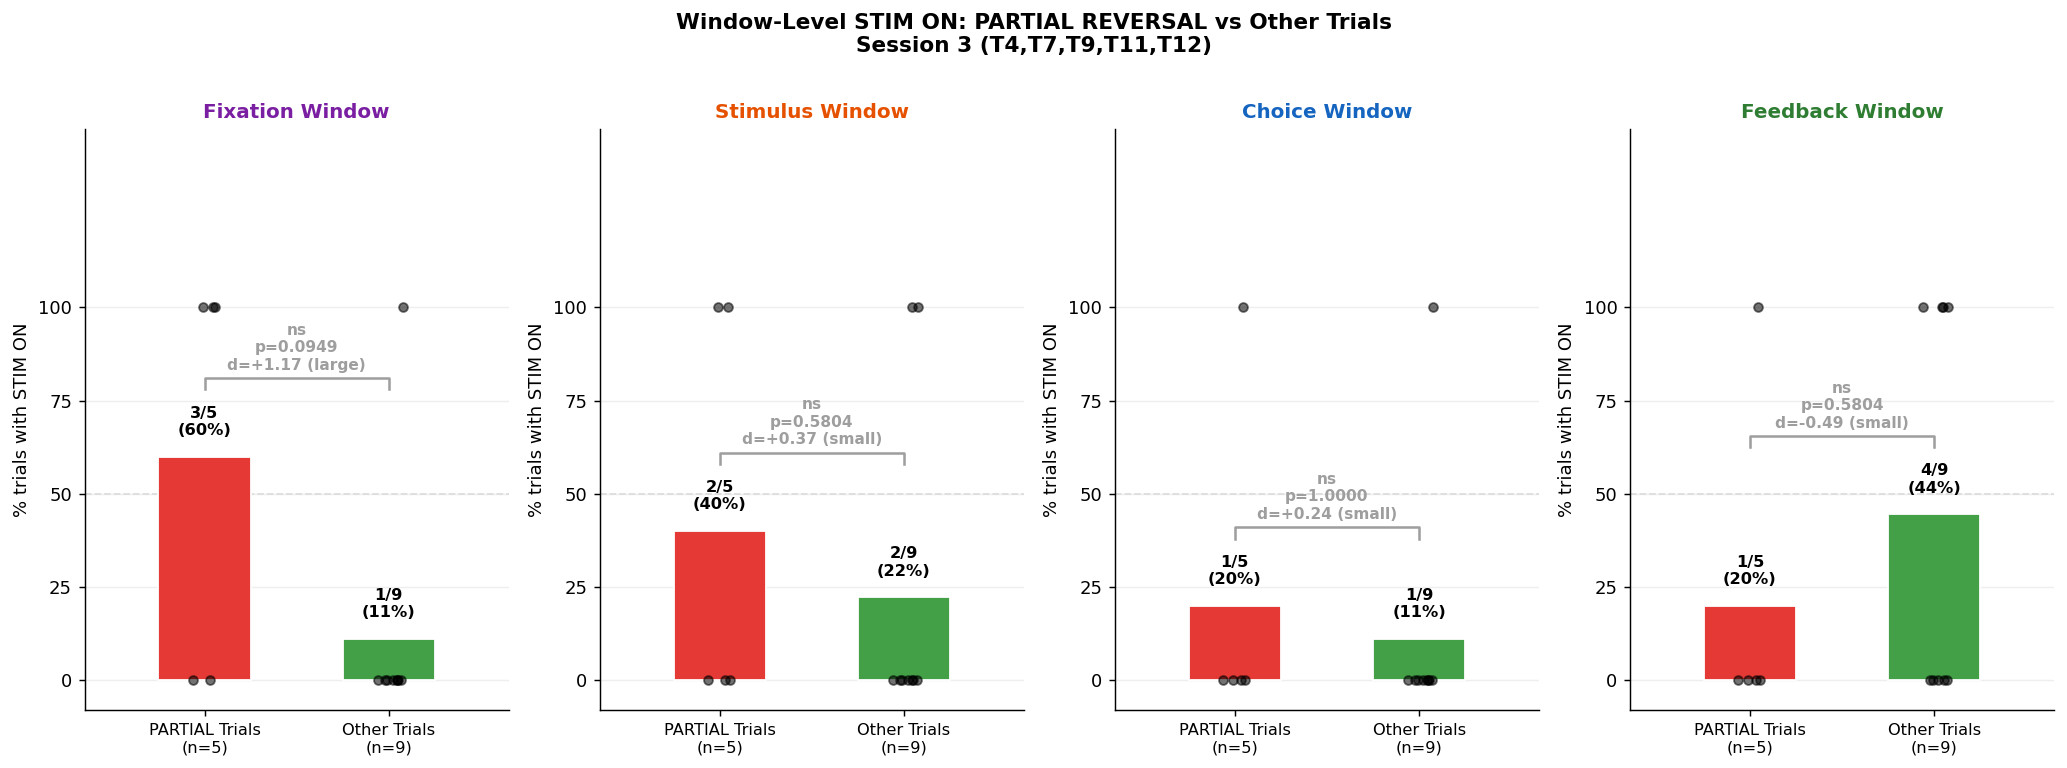


  Combined (8 PARTIAL trials) — PARTIAL REVERSAL vs Other Trials: % STIM ON per window
  PARTIAL (n=8) vs Other (n=20)
  Window        PARTIAL ON   Other ON         p  stars         d  Effect
  ----------------------------------------------------------------------
  Fixation     6/8 (75%)   7/20 (35%)   p=0.0957    ns  d=+0.829  (large)
  Stimulus     5/8 (62%)   8/20 (40%)   p=0.4097    ns  d=+0.444  (small)
  Choice       4/8 (50%)   6/20 (30%)   p=0.4004    ns  d=+0.410  (small)
  Feedback     4/8 (50%)   9/20 (45%)   p=1.0000    ns  d=+0.097  (negligible)
Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\window_stats_partial_vs_other_(8.png


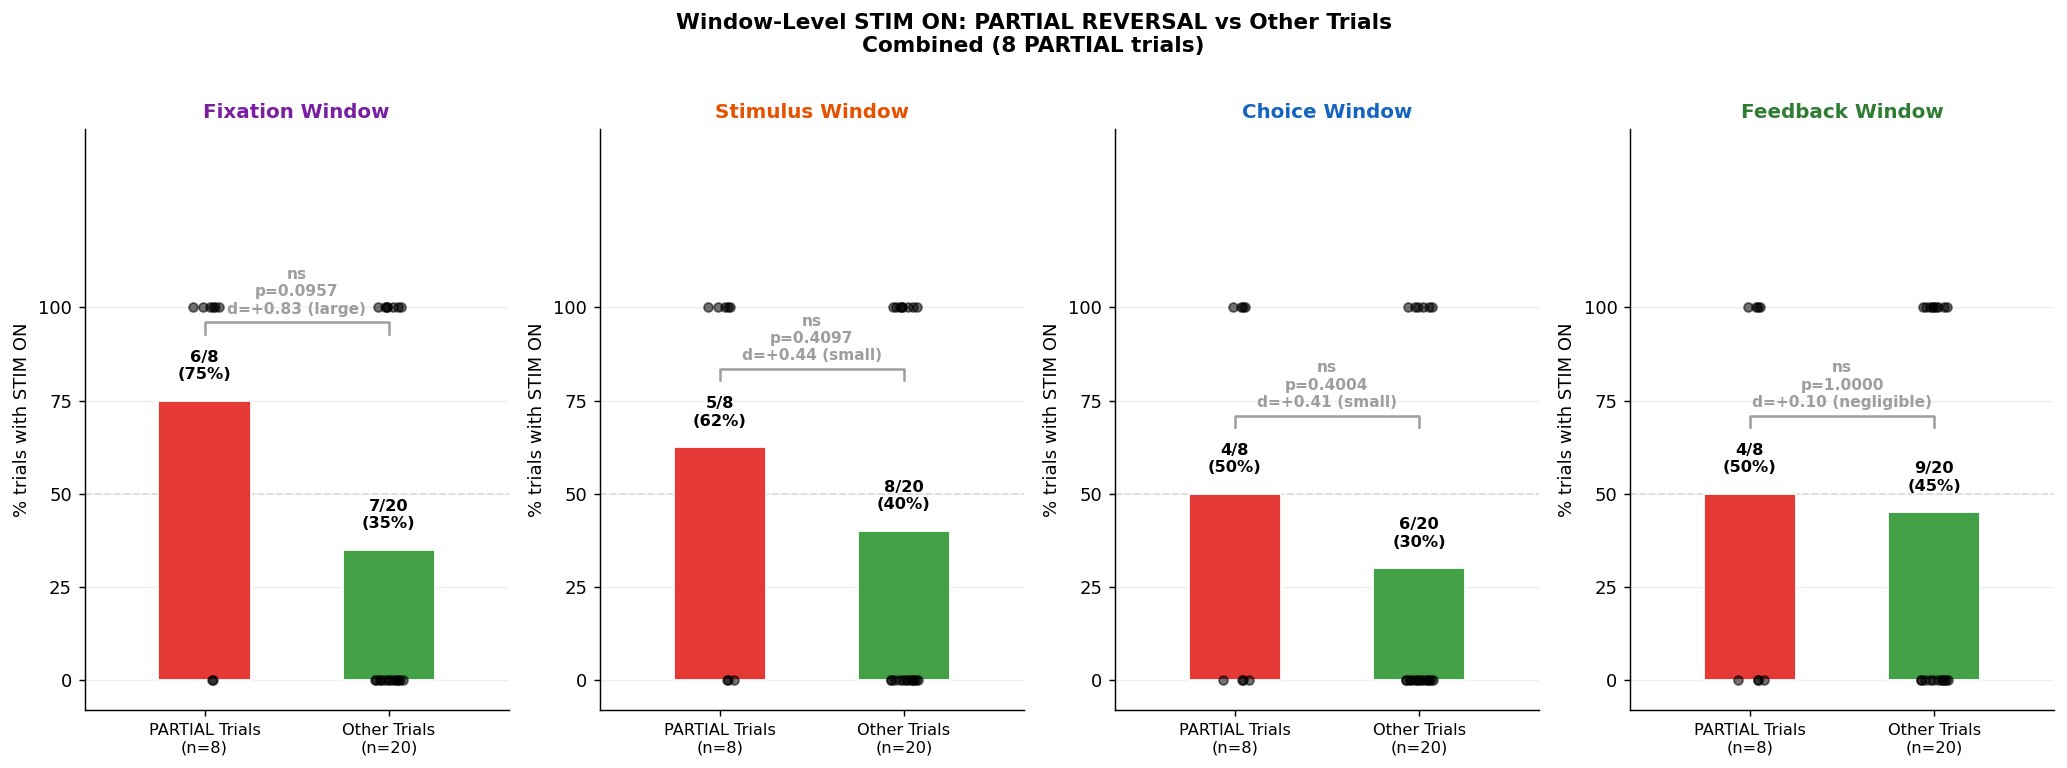

In [17]:
# Compare PARTIAL REVERSAL target trials vs all other (non-target) trials.
# Asks: were the PARTIAL REVERSAL trials more/less stimulated than the rest?

for sess_label, df_target, df_full, odir in [
    ('Session 2 (T7,T10,T14)',           df_s2,
     trials_to_df(build_trials(ep_s2, ev_s2, to_rel_s2, tr_s2, mA_s2, 'Session 2')),
     OUT_DIR_S2),
    ('Session 3 (T4,T7,T9,T11,T12)',     df_s3,
     trials_to_df(build_trials(ep_s3, ev_s3, to_rel_s3, tr_s3, mA_s3, 'Session 3')),
     OUT_DIR_S3),
    ('Combined (8 PARTIAL trials)',       df_all,
     pd.concat([
         trials_to_df(build_trials(ep_s2, ev_s2, to_rel_s2, tr_s2, mA_s2, 'Session 2')),
         trials_to_df(build_trials(ep_s3, ev_s3, to_rel_s3, tr_s3, mA_s3, 'Session 3'))
     ], ignore_index=True), COMBINED_DIR),
]:
    target_nums_s2 = set(TARGET_TRIALS_S2)
    target_nums_s3 = set(TARGET_TRIALS_S3)

    def is_target(row):
        if row['session'] == 'Session 2': return row['trial_num'] in target_nums_s2
        if row['session'] == 'Session 3': return row['trial_num'] in target_nums_s3
        return False

    df_full['is_target'] = df_full.apply(is_target, axis=1)
    mask_target = df_full['is_target'] == True
    mask_other  = df_full['is_target'] == False

    if mask_target.sum() == 0 or mask_other.sum() == 0:
        print(f'{sess_label}: not enough groups to compare'); continue

    st = window_stats_comparison(df_full, mask_target, mask_other,
                                  'PARTIAL Trials', 'Other Trials')

    print(f'\n{"="*72}')
    print(f'  {sess_label} — PARTIAL REVERSAL vs Other Trials: % STIM ON per window')
    print(f'  PARTIAL (n={mask_target.sum()}) vs Other (n={mask_other.sum()})')
    print(f'{"="*72}')
    print(f'  {"Window":<12} {"PARTIAL ON":>11} {"Other ON":>10}  {"p":>8}  {"stars":>5}  {"d":>8}  Effect')
    print(f'  {"-"*70}')
    for _, r in st.iterrows():
        p_s = f'{r["p"]:.4f}' if not np.isnan(r['p']) else 'N/A'
        d_s = f'{r["d"]:+.3f}' if not np.isnan(r['d']) else 'N/A'
        print(f'  {r["Window"]:<12} '
              f'{r["n_on_a"]}/{r["n_a"]} ({r["pct_a"]})   '
              f'{r["n_on_b"]}/{r["n_b"]} ({r["pct_b"]})   '
              f'p={p_s}  {r["stars"]:>4}  d={d_s}  ({r["effect"]})')

    plot_window_stats(
        st,
        title=f'Window-Level STIM ON: PARTIAL REVERSAL vs Other Trials\n{sess_label}',
        save_path=Path(odir) / f'window_stats_partial_vs_other_{sess_label.split()[1]}.png'
    )

## Cell 14 — Summary Table + CSV Export

In [18]:
all_rows = []

df_s2_full  = trials_to_df(build_trials(ep_s2, ev_s2, to_rel_s2, tr_s2, mA_s2, 'Session 2'))
df_s3_full  = trials_to_df(build_trials(ep_s3, ev_s3, to_rel_s3, tr_s3, mA_s3, 'Session 3'))
df_full_all = pd.concat([df_s2_full, df_s3_full], ignore_index=True)

def mark_targets(df):
    def is_t(row):
        if row['session'] == 'Session 2': return row['trial_num'] in TARGET_TRIALS_S2
        if row['session'] == 'Session 3': return row['trial_num'] in TARGET_TRIALS_S3
        return False
    df = df.copy()
    df['is_target'] = df.apply(is_t, axis=1)
    return df

df_s2_full  = mark_targets(df_s2_full)
df_s3_full  = mark_targets(df_s3_full)
df_full_all = mark_targets(df_full_all)

for sess_label, df in [
    ('Session 2 (T7,T10,T14)',          df_s2_full),
    ('Session 3 (T4,T7,T9,T11,T12)',    df_s3_full),
    ('Combined (8 PARTIAL trials)',      df_full_all),
]:
    mask_t = df['is_target'] == True
    mask_o = df['is_target'] == False
    for wc, wl in [('stim_fix','Fixation'), ('stim_stim','Stimulus'),
                   ('stim_choice','Choice'), ('stim_feedback','Feedback')]:
        a = df[mask_t][wc].astype(float).values
        b = df[mask_o][wc].astype(float).values
        p = fisher_p(int(a.sum()), len(a), int(b.sum()), len(b))
        d = cohens_d(a, b)
        all_rows.append(dict(
            Session         = sess_label,
            Window          = wl,
            N_PARTIAL       = len(a),
            StimON_PARTIAL  = f"{int(a.sum())}/{len(a)} ({a.mean()*100:.0f}%)" if len(a) else '—',
            N_Other         = len(b),
            StimON_Other    = f"{int(b.sum())}/{len(b)} ({b.mean()*100:.0f}%)" if len(b) else '—',
            p_value         = f'{p:.4f}' if not np.isnan(p) else 'N/A',
            Stars           = sig_stars(p),
            Cohens_d        = f'{d:+.3f}' if not np.isnan(d) else 'N/A',
            Effect_Size     = d_label(d),
        ))

summary_df = pd.DataFrame(all_rows)
display(summary_df)
summary_df.to_csv(COMBINED_DIR / 'partial_reversal_stim_stats.csv', index=False)
print(f'\nSaved -> {COMBINED_DIR / "partial_reversal_stim_stats.csv"}')

Session 2: 14 trials
  PARTIAL_REVERSAL: 3
  CORRECT: 6
Session 3: 14 trials
  PARTIAL_REVERSAL: 5
  CORRECT: 8


,Session,Window,N_PARTIAL,StimON_PARTIAL,N_Other,StimON_Other,p_value,Stars,Cohens_d,Effect_Size
0,"Session 2 (T7,T10,T14)",Fixation,3,3/3 (100%),11,6/11 (55%),0.2582,ns,+0.953,large
1,"Session 2 (T7,T10,T14)",Stimulus,3,3/3 (100%),11,6/11 (55%),0.2582,ns,+0.953,large
2,"Session 2 (T7,T10,T14)",Choice,3,3/3 (100%),11,5/11 (45%),0.2088,ns,+1.144,large
3,"Session 2 (T7,T10,T14)",Feedback,3,3/3 (100%),11,5/11 (45%),0.2088,ns,+1.144,large
4,"Session 3 (T4,T7,T9,T11,T12)",Fixation,5,3/5 (60%),9,1/9 (11%),0.0949,ns,+1.172,large
5,"Session 3 (T4,T7,T9,T11,T12)",Stimulus,5,2/5 (40%),9,2/9 (22%),0.5804,ns,+0.371,small
6,"Session 3 (T4,T7,T9,T11,T12)",Choice,5,1/5 (20%),9,1/9 (11%),1.0000,ns,+0.237,small
7,"Session 3 (T4,T7,T9,T11,T12)",Feedback,5,1/5 (20%),9,4/9 (44%),0.5804,ns,-0.487,small
8,Combined (8 PARTIAL trials),Fixation,8,6/8 (75%),20,7/20 (35%),0.0957,ns,+0.829,large
9,Combined (8 PARTIAL trials),Stimulus,8,5/8 (62%),20,8/20 (40%),0.4097,ns,+0.444,small



Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\partial_reversal_stim_stats.csv
